In [1]:
# Grundlegende Bibliotheken
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from yellowbrick.cluster import KElbowVisualizer

# Vorverarbeitung und Skalierung
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, label_binarize

# Modellierung – Regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Modellierung – Klassifikation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Modellauswahl und Hyperparameter
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, validation_curve

# Regressionsmetriken
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error
)

# Klassifikationsmetriken
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Clustering und Dimensionsreduktion
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cophenet
from scipy.spatial.distance import pdist

In [2]:
print(os.getcwd())

C:\Users\nesri\repos\bitirme projesi\GlobalDentalStats-1\notebooks


In [ ]:
df = pd.read_excel("../data/processed_data/merged_data.xlsx")

In [4]:
df.head(5)

,Location,Period,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases
0,Angola,2019,70.2,2.3,4.0,23.9,27.2,37.8,195.8,482,166,316
1,Burundi,2019,1.3,0.1,2.0,19.2,31.7,41.6,5.3,92,30,62
2,Benin,2019,3.3,0.3,2.9,27.1,29.5,39.6,30.0,74,42,32
3,Burkina Faso,2019,4.6,0.2,1.9,27.4,27.5,40.3,30.8,179,55,124
4,Botswana,2019,57.4,24.1,7.5,26.3,32.7,37.6,59.2,60,8,52


| Spaltenname                    | Beschreibung                                                                |
|--------------------------------|----------------------------------------------------------------------------|
| Location                       | Ländername (z. B.: Angola)                                                 |
| Period                         | Datenjahr (z. B.: 2019)                                                    |
| TotalExpenditure               | Ausgaben für Zahnmedizin – Gesamtausgaben (Millionen USD)                  |
| PerCapitaExpenditure           | Pro-Kopf-Ausgaben für Zahnmedizin (USD)                                    |
| EdentulismRate                 | Zahnlosigkeit bei Personen über 20 Jahren (%)                              |
| PeriodontalRate                | Prävalenz schwerer Parodontalerkrankungen bei Personen über 15 Jahren (%) |
| UntreatedCariesRate            | Prävalenz unbehandelter Karies an bleibenden Zähnen bei Personen über 5 (%)|
| UntreatedDeciduousCaries1_9Rate| Prävalenz unbehandelter Milchzahnkaries bei Kindern im Alter von 1–9 Jahren|
| ProductivityLoss               | Gesamtproduktivitätsverlust aufgrund von 5 Mundkrankheiten (Millionen USD)|
| TotalCancerNewCases            | Lippen- und Mundhöhlenkrebs: Neue Fälle in der Gesamtbevölkerung           |
| FemaleCancerNewCases           | Lippen- und Mundhöhlenkrebs: Neue Fälle bei Frauen                         |
| MaleCancerNewCases             | Lippen- und Mundhöhlenkrebs: Neue Fälle bei Männern                        |

In [5]:
# Um in allen String-Spalten alle Leerzeichen am Anfang, am Ende und in der Mitte der Zellen zu entfernen
df = df.apply(lambda col: col.str.strip().str.replace(" ", "") if col.dtype == "object" else col)

In [6]:
# Um zu prüfen, ob ein DataFrame doppelte Zeilen enthält
df.duplicated().any()

np.False_

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Location                         192 non-null    object 
 1   Period                           192 non-null    int64  
 2   TotalExpenditure                 192 non-null    object 
 3   PerCapitaExpenditure             192 non-null    float64
 4   EdentulismRate                   192 non-null    float64
 5   PeriodontalRate                  192 non-null    float64
 6   UntreatedCariesRate              192 non-null    float64
 7   UntreatedDeciduousCaries1_9Rate  192 non-null    float64
 8   ProductivityLoss                 192 non-null    object 
 9   TotalCancerNewCases              174 non-null    object 
 10  FemaleCancerNewCases             171 non-null    object 
 11  MaleCancerNewCases               174 non-null    object 
dtypes: float64(5), int64(1

In [8]:
# Numerische Spalten in numerische Datentypen umwandeln
# Alle Spalten außer 'Period' und 'Location' auswählen und in numerische Datentypen konvertieren
cols_to_convert = [col for col in df.columns if col not in ['Period', 'Location']]

# Ausgewählte Spalten in den numerischen Datentyp umwandeln (nicht konvertierbare Werte werden zu NaN)
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [9]:
df.dtypes

Location                            object
Period                               int64
TotalExpenditure                   float64
PerCapitaExpenditure               float64
EdentulismRate                     float64
PeriodontalRate                    float64
UntreatedCariesRate                float64
UntreatedDeciduousCaries1_9Rate    float64
ProductivityLoss                   float64
TotalCancerNewCases                float64
FemaleCancerNewCases               float64
MaleCancerNewCases                 float64
dtype: object

In [10]:
# Um die Spalte 'Period' zu entfernen
df = df.drop(columns=['Period'])

In [11]:
# Um die Zeilen anzuzeigen, in denen die Spalte 'TotalCancerNewCases' gefüllt ist und die Spalte 'FemaleCancerNewCases' leer ist
df[df["FemaleCancerNewCases"].isna() & df["TotalCancerNewCases"].notna()]

,Location,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases
10,Comoros,0.3,0.3,2.9,22.8,32.3,40.3,2.7,5.0,NaN,5.0
49,Bahamas,32.9,514.9,6.4,25.9,28.7,43.9,47.8,5.0,NaN,5.0
161,Maldives,0.6,1.7,3.2,8.1,28.0,44.0,15.5,5.0,NaN,5.0


In [12]:
# Um in den Zeilen, in denen 'TotalCancerNewCases' gefüllt ist und 'FemaleCancerNewCases' leer ist, die NaN‑Werte mit 0 zu füllen
df.loc[df["FemaleCancerNewCases"].isna() & df["TotalCancerNewCases"].notna(),"FemaleCancerNewCases"] = 0

In [13]:
# Kontrollieren
df[df["FemaleCancerNewCases"].isna() & df["TotalCancerNewCases"].notna()]

,Location,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TotalExpenditure,192.0,2016.106771,11135.195720,0.0,3.500,45.60,227.275,133505.8
PerCapitaExpenditure,192.0,54.919271,115.728152,0.0,0.675,9.20,39.525,867.2
EdentulismRate,192.0,7.644792,3.965027,1.2,4.300,7.50,10.625,16.8
PeriodontalRate,192.0,18.439583,6.910702,2.3,15.175,19.20,23.725,33.5
UntreatedCariesRate,192.0,32.256250,4.520687,21.9,29.200,31.85,35.500,49.5
UntreatedDeciduousCaries1_9Rate,192.0,41.733854,6.347399,18.7,39.075,43.60,46.500,53.2
ProductivityLoss,192.0,1680.660417,7038.217347,0.1,21.950,103.65,744.250,78468.5
TotalCancerNewCases,174.0,2124.356322,10860.615852,2.0,60.250,203.00,858.250,135929.0
FemaleCancerNewCases,174.0,646.954023,2673.235330,0.0,23.250,89.50,302.000,31268.0
MaleCancerNewCases,174.0,1477.402299,8238.145004,1.0,38.250,122.50,565.250,104661.0


In [15]:
# Um die Anzahl der fehlenden (NaN) Werte in jeder Spalte zu überprüfen
print(df.isna().sum())

Location                            0
TotalExpenditure                    0
PerCapitaExpenditure                0
EdentulismRate                      0
PeriodontalRate                     0
UntreatedCariesRate                 0
UntreatedDeciduousCaries1_9Rate     0
ProductivityLoss                    0
TotalCancerNewCases                18
FemaleCancerNewCases               18
MaleCancerNewCases                 18
dtype: int64


In [16]:
# Um alle Zeilen auszuwählen, die fehlende (NaN) Werte enthalten
missing_rows = df[df.isna().any(axis=1)]

# Um die Länder aufzulisten, die fehlende Werte enthalten
missing_countries = missing_rows['Location'].unique()
print(missing_countries)

['SaoTomeandPrincipe' 'Seychelles' 'AntiguaandBarbuda' 'Belize' 'Dominica'
 'Grenada' 'SaintKittsandNevis' 'SaintVincentandtheGrenadines' 'Andorra'
 'Monaco' 'SanMarino' 'Micronesia' 'Kiribati' 'MarshallIslands' 'Nauru'
 'Palau' 'Tonga' 'Tuvalu']


In [17]:
# Für die Krebsspalten (Total/Female/Male) lassen wir die NaN-Werte unverändert.
# Wir füllen fehlende Werte nicht mit 0, damit während der Analyse keine falschen Interpretationen entstehen.

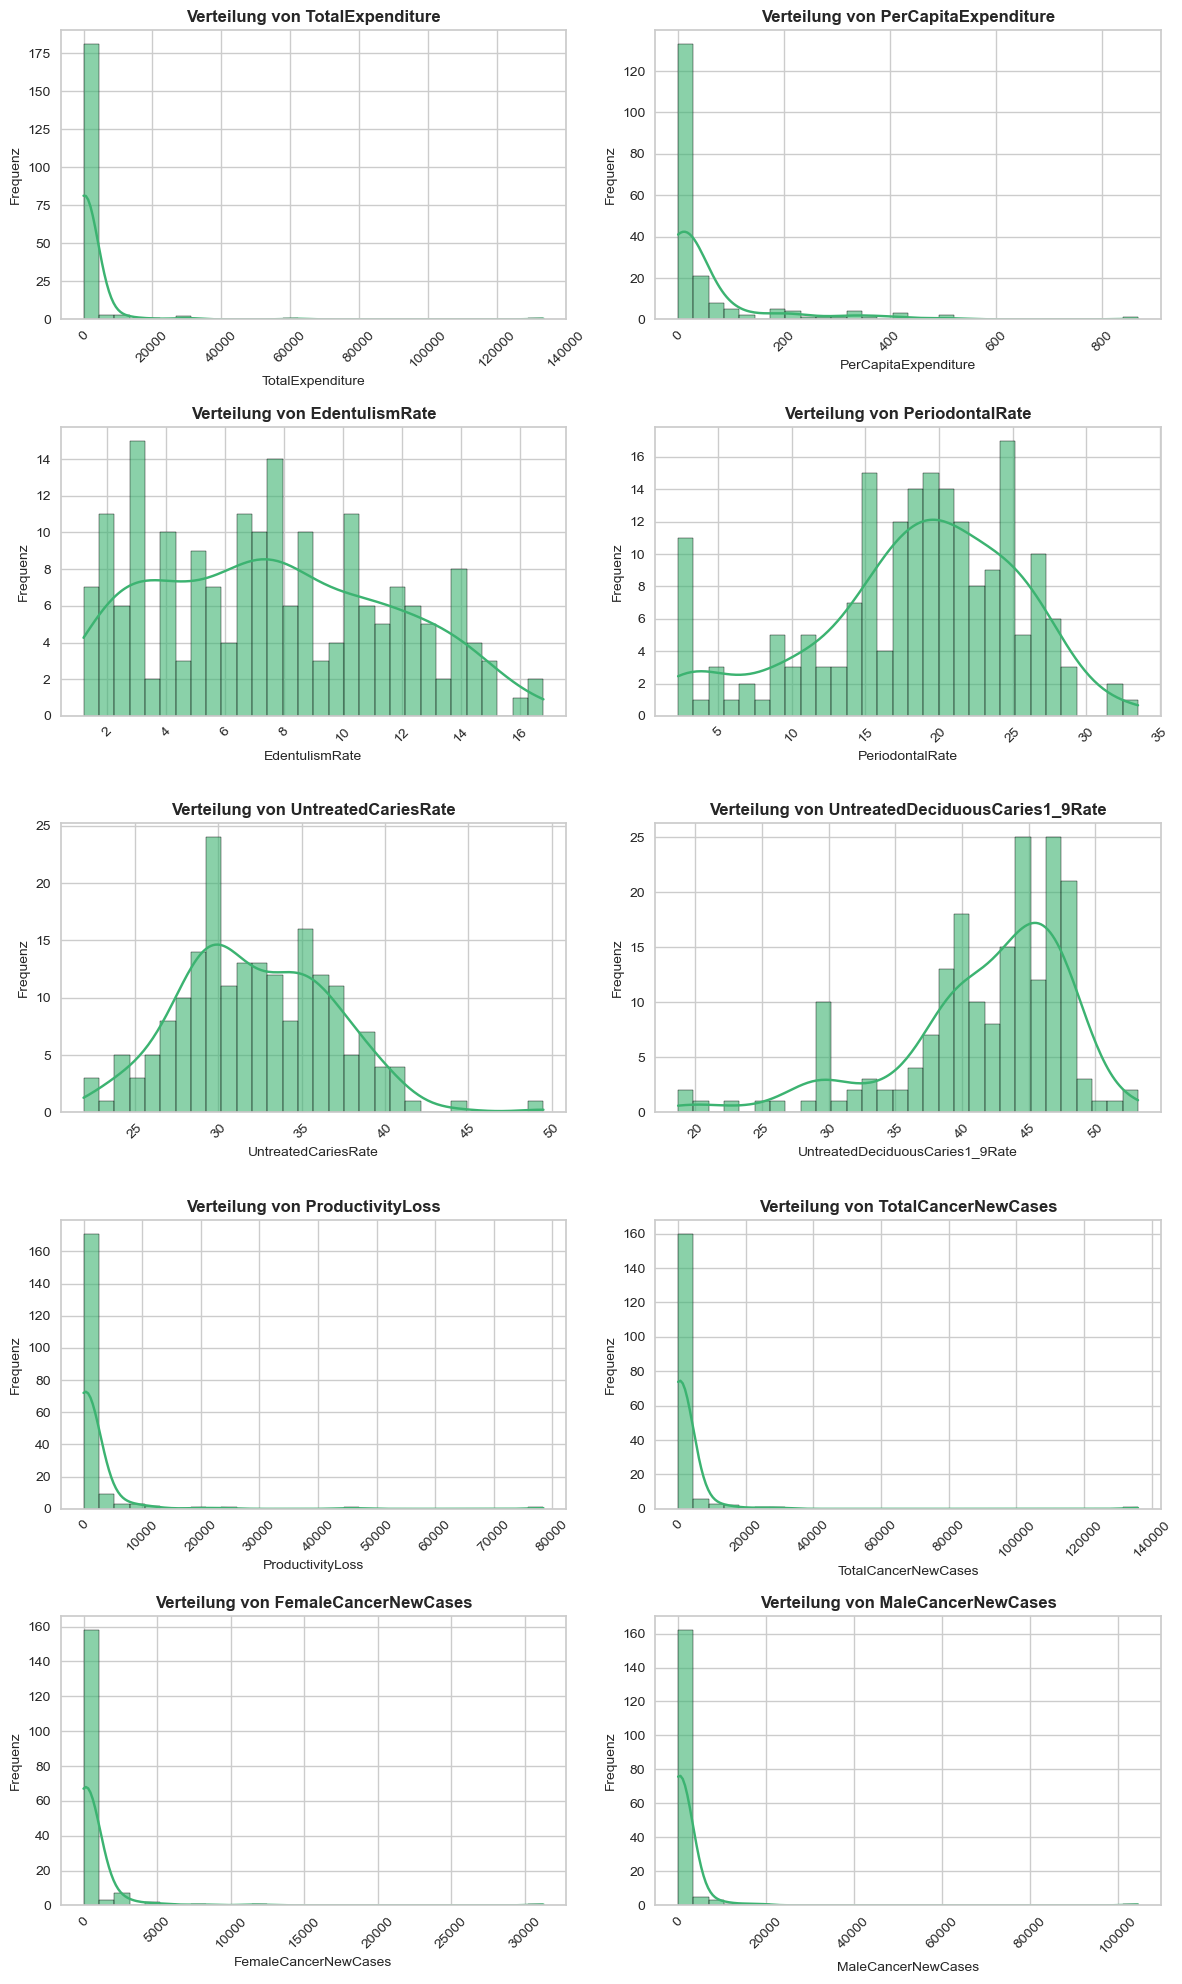

In [18]:
# Histogramme und KDE‑Diagramme für alle numerischen Spalten
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 2
n_rows = (len(numeric_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))

for i, col in enumerate(numeric_cols):
    row = i // n_cols
    col_idx = i % n_cols
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]
    
    sns.histplot(df[col], bins=30, kde=True, ax=ax,
                 color='mediumseagreen', edgecolor='black', alpha=0.6)
    
    ax.set_title(f"Verteilung von {col}", fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Frequenz", fontsize=10)
    ax.tick_params(axis='x', rotation=45)

if len(numeric_cols) % n_cols != 0:
    for j in range(len(numeric_cols), n_rows*n_cols):
        fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

In [19]:
# Die 10 Länder mit den höchsten Ausgaben für Zahngesundheit
# Um die 10 Länder mit den höchsten Gesamtausgaben zu ermitteln
top_total_expenditure = df.sort_values("TotalExpenditure", ascending=False).head(10)

print("Die 10 Länder mit den höchsten Gesamtausgaben:")
print(top_total_expenditure[["Location", "TotalExpenditure", "PerCapitaExpenditure"]].to_string(index=False))

Die 10 Länder mit den höchsten Gesamtausgaben:
     Location  TotalExpenditure  PerCapitaExpenditure
 UnitedStates          133505.8                 405.5
        China           61548.6                  44.0
      Germany           30877.3                 372.2
        Japan           28733.6                 227.7
        Italy           19123.0                 316.8
       Canada           12829.1                 342.5
       France           12666.0                 195.4
UnitedKingdom            9576.9                 143.2
        Spain            8306.3                 178.0
    Australia            7370.3                 288.3


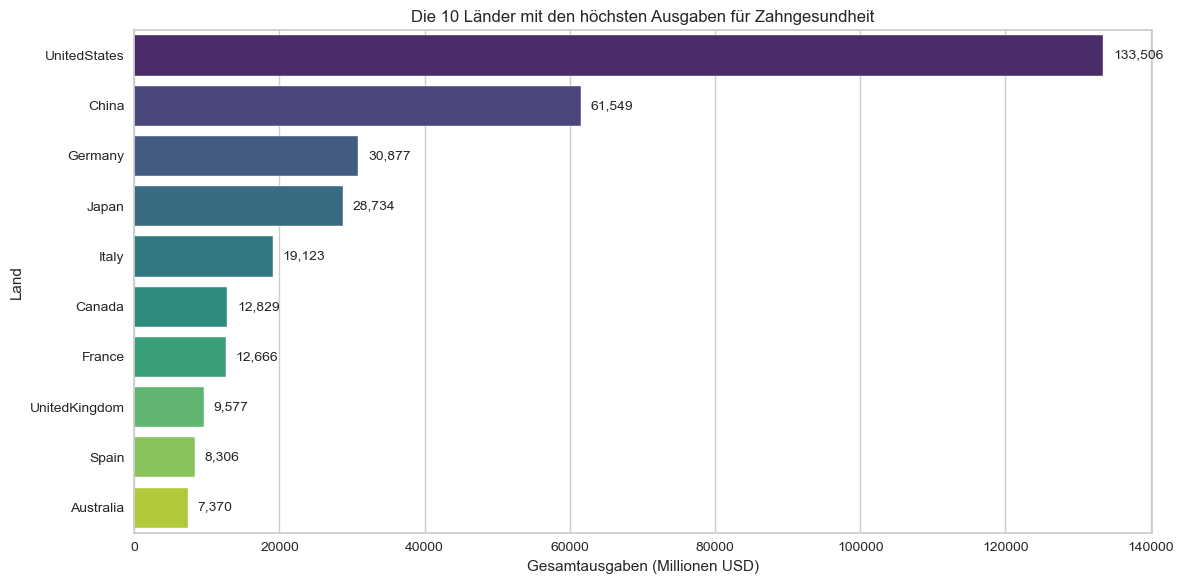

In [20]:
# Die 10 Länder mit den höchsten Ausgaben für Zahngesundheit
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("viridis", len(top_total_expenditure))
ax = sns.barplot(
    x="TotalExpenditure",
    y="Location",
    data=top_total_expenditure,
    palette=colors,
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + (0.01 * top_total_expenditure["TotalExpenditure"].max()),
        p.get_y() + p.get_height() / 2,
        f"{width:,.0f}",
        ha="left", va="center", fontsize=10
    )

plt.title("Die 10 Länder mit den höchsten Ausgaben für Zahngesundheit", fontsize=12)
plt.xlabel("Gesamtausgaben (Millionen USD)")
plt.ylabel("Land")

plt.tight_layout()
plt.show()

In [21]:
# Die 10 Länder mit den niedrigsten Ausgaben für Zahngesundheit
# Um die 10 Länder mit den niedrigsten Gesamtausgaben auszuwählen
low_total_expenditure = df.sort_values("TotalExpenditure", ascending=True).head(10)

print("\nDie 10 Länder mit den niedrigsten Gesamtausgaben:")
print(low_total_expenditure[["Location", "TotalExpenditure", "PerCapitaExpenditure"]].to_string(index=False))


Die 10 Länder mit den niedrigsten Gesamtausgaben:
          Location  TotalExpenditure  PerCapitaExpenditure
             Kenya               0.0                   0.0
             Niger               0.0                   0.0
            Gambia               0.0                   0.0
              Iraq               0.0                   0.0
          Cambodia               0.0                   0.0
            Bhutan               0.0                   0.1
          Tanzania               0.1                   0.0
SaoTomeandPrincipe               0.1                   0.6
           Vanuatu               0.1                   0.5
            Tuvalu               0.1                   6.8


In [22]:
# Gesundheitsindikatoren (%) der 10 Länder mit den höchsten Ausgaben für Zahngesundheit
health_cols = ["EdentulismRate", "PeriodontalRate", "UntreatedCariesRate",
               "UntreatedDeciduousCaries1_9Rate"]
df_top_spenders_health = top_total_expenditure[["Location"] + health_cols]

print("\nGesundheitsindikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit (%):")
print(df_top_spenders_health.to_string(index=False))


Gesundheitsindikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit (%):
     Location  EdentulismRate  PeriodontalRate  UntreatedCariesRate  UntreatedDeciduousCaries1_9Rate
 UnitedStates            10.2             15.7                 24.3                             42.6
        China             5.7             17.5                 24.6                             47.2
      Germany            11.7             27.4                 31.7                             29.1
        Japan            11.7             20.6                 25.8                             39.5
        Italy            12.9             18.2                 29.6                             36.1
       Canada             7.7             24.7                 25.1                             38.9
       France            12.6             16.2                 36.8                             29.2
UnitedKingdom            12.0             10.6                 30.6                             19.5
   

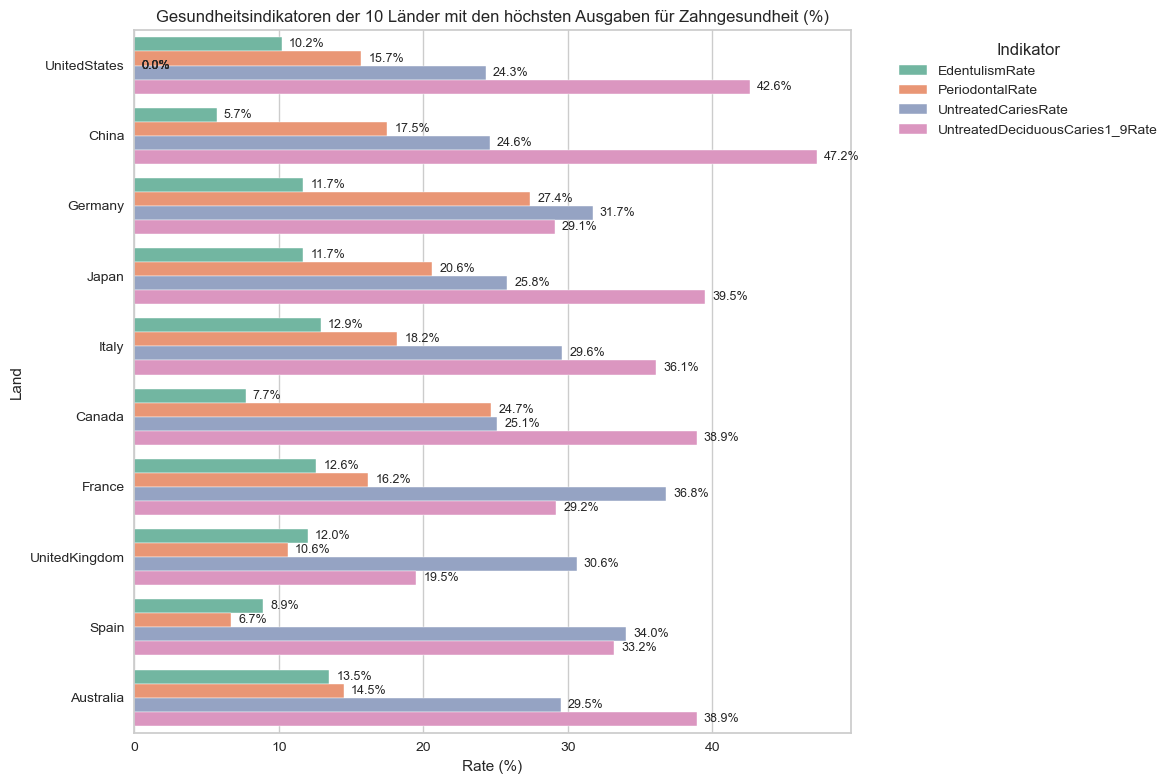

In [23]:
# Gesundheitsindikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit (%)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

df_melted = df_top_spenders_health.melt(id_vars="Location", 
                                        var_name="Indicator", 
                                        value_name="Rate")


ax = sns.barplot(y="Location", x="Rate", hue="Indicator", data=df_melted, palette="Set2")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2,
            f"{width:.1f}%", ha='left', va='center', fontsize=9)

plt.title("Gesundheitsindikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit (%)", fontsize=12)
plt.xlabel("Rate (%)")
plt.ylabel("Land")

plt.legend(title="Indikator", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

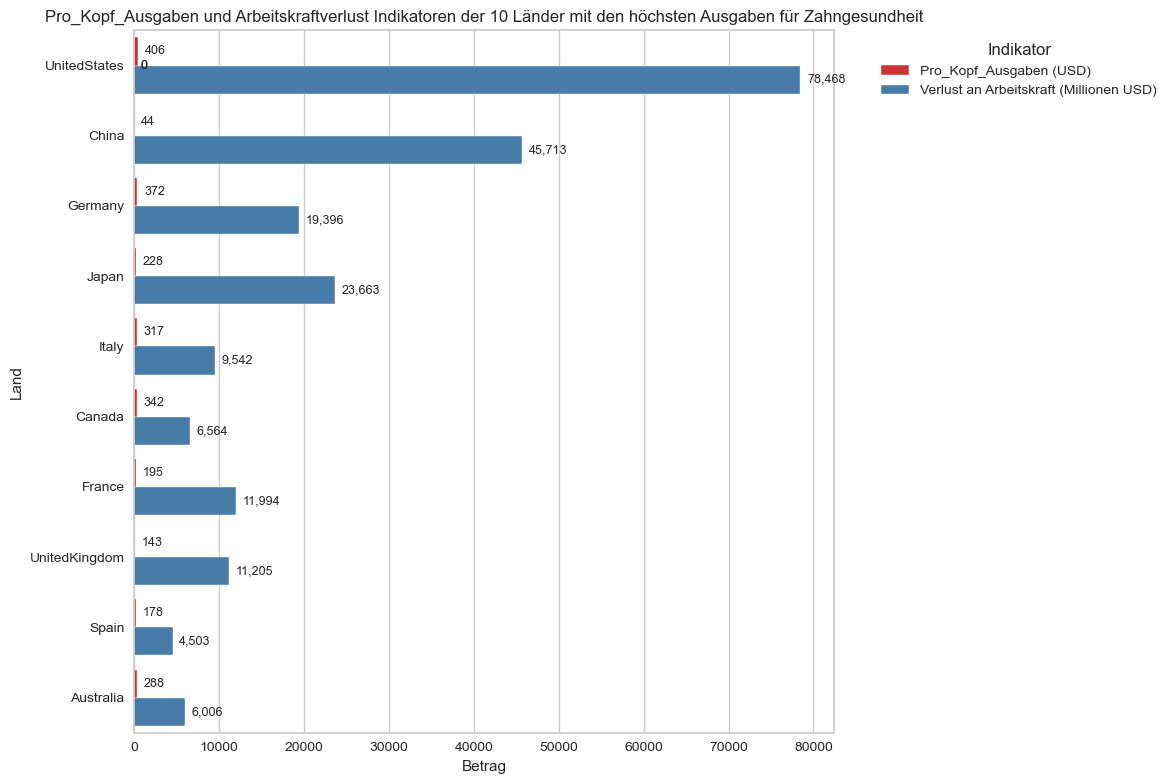

In [24]:
# Pro‑Kopf‑Ausgaben und Arbeitskraftverlust‑Indikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit
amount_cols = ["PerCapitaExpenditure", "ProductivityLoss"]

df_top_spenders_amount = top_total_expenditure[["Location"] + amount_cols].copy()
df_top_spenders_amount.rename(columns={
    "PerCapitaExpenditure": "Pro_Kopf_Ausgaben (USD)",
    "ProductivityLoss": "Verlust an Arbeitskraft (Millionen USD)"
}, inplace=True)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

df_melted_amount = df_top_spenders_amount.melt(id_vars="Location", 
                                               var_name="Indikator", 
                                               value_name="Betrag")

ax = sns.barplot(y="Location", x="Betrag", hue="Indikator", data=df_melted_amount, palette="Set1")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01 * df_melted_amount["Betrag"].max(),
            p.get_y() + p.get_height()/2,
            f"{width:,.0f}",
            ha='left', va='center', fontsize=9)

plt.title("Pro_Kopf_Ausgaben und Arbeitskraftverlust Indikatoren der 10 Länder mit den höchsten Ausgaben für Zahngesundheit", fontsize=12)
plt.xlabel("Betrag")
plt.ylabel("Land")

plt.legend(title="Indikator", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

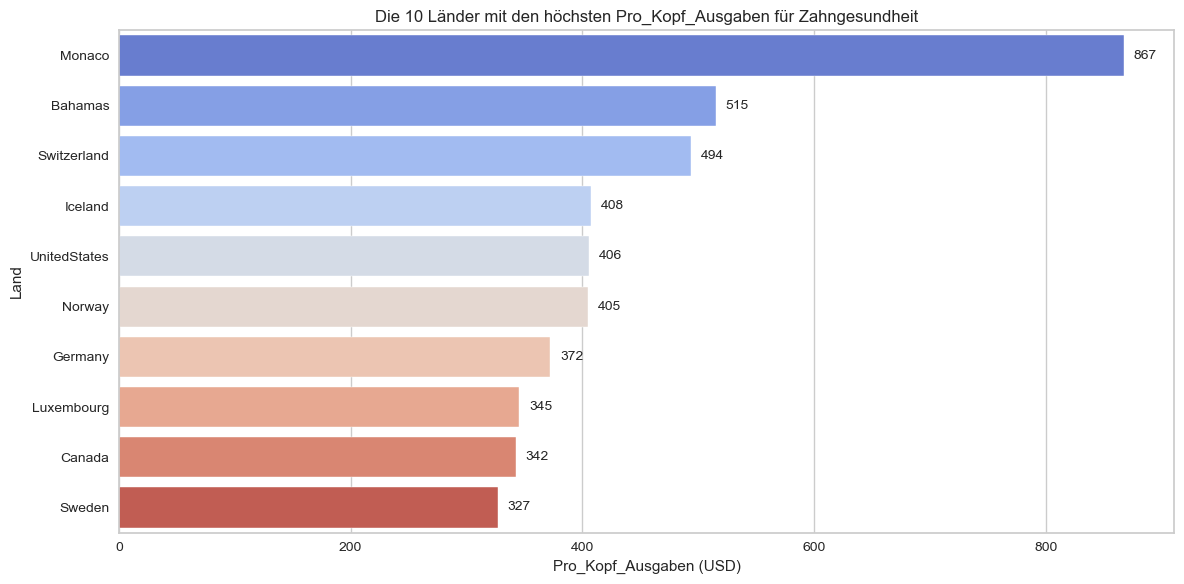

In [25]:
# Die 10 Länder mit den höchsten Pro‑Kopf‑Ausgaben für Zahngesundheit
sorted_df = df.sort_values("PerCapitaExpenditure", ascending=False)

top10_per_capita = sorted_df.head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x="PerCapitaExpenditure",
    y="Location",
    data=top10_per_capita,
    palette="coolwarm"
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + (0.01 * top10_per_capita["PerCapitaExpenditure"].max()),
        p.get_y() + p.get_height() / 2,
        f"{width:,.0f}",
        ha="left", va="center", fontsize=10
    )

plt.title("Die 10 Länder mit den höchsten Pro_Kopf_Ausgaben für Zahngesundheit", fontsize=12)
plt.xlabel("Pro_Kopf_Ausgaben (USD)")
plt.ylabel("Land")
plt.tight_layout()
plt.show()

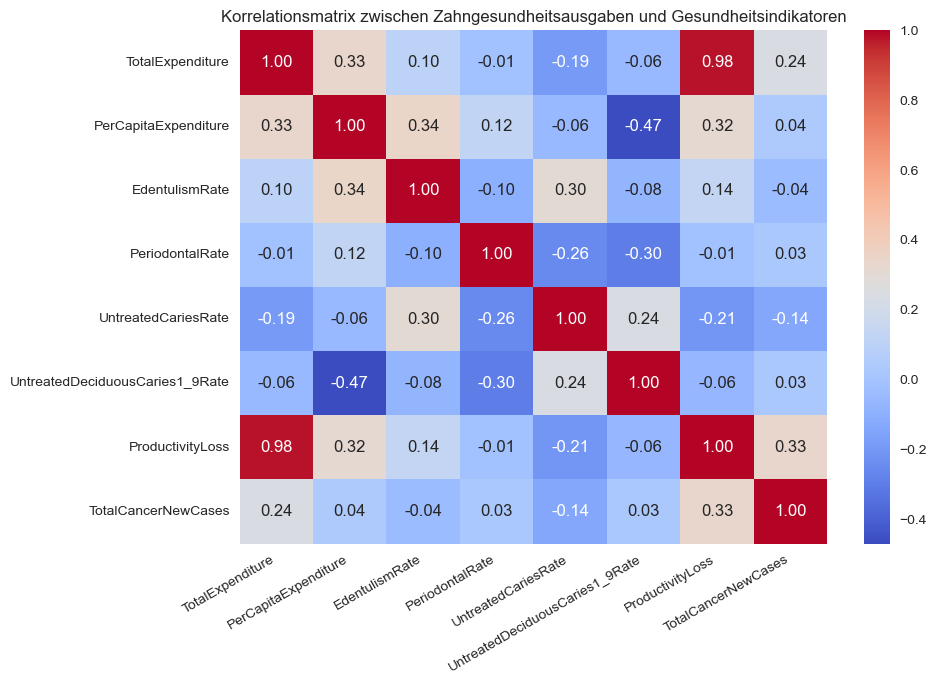

In [26]:
# Korrelationsmatrix zwischen Zahngesundheitsausgaben und Gesundheitsindikatoren

numeric_for_corr = [col for col in df.columns if col not in ['Location','FemaleCancerNewCases', 'MaleCancerNewCases']]

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(10, 7))
ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Korrelationsmatrix zwischen Zahngesundheitsausgaben und Gesundheitsindikatoren", fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
# Durchschnittliche Mundgesundheitsindikatoren nach Gesamtausgabengruppen

# Einteilung von TotalExpenditure in 3 Gruppen (Low, Medium, High) mithilfe von Quantilen
df["ExpenditureGroup"] = pd.qcut(df["TotalExpenditure"], 3, labels=["Low", "Medium", "High"])

# Mundgesundheitsindikatoren und Pro-Kopf-Ausgabenspalten
health_cols = [
    "EdentulismRate",
    "PeriodontalRate",
    "UntreatedCariesRate",
    "UntreatedDeciduousCaries1_9Rate",
    "ProductivityLoss",
    "PerCapitaExpenditure"
]

# Berechnung der Durchschnittswerte nach Ausgabengruppe
grouped_health = df.groupby("ExpenditureGroup")[health_cols].mean()

# Visualisierung der Tabelle mit Stilformatierung
styled_table = (
    grouped_health.style
    .format("{:.2f}")                            
    .background_gradient(cmap="coolwarm")         
    .set_caption("Durchschnittliche Mundgesundheitsindikatoren und Pro-Kopf-Ausgaben nach Gesamtausgabengruppen")
    .set_table_styles([{
        'selector': 'caption',
        'props': [
            ('color', 'black'),
            ('font-size', '12px'),
            ('font-weight', 'bold')
        ]
    }])
)

styled_table


,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,PerCapitaExpenditure
ExpenditureGroup,,,,,,
Low,4.49,18.70,31.63,42.22,37.33,5.76
Medium,8.45,17.73,32.61,43.01,273.85,40.53
High,10.00,18.89,32.53,39.97,4730.80,118.47


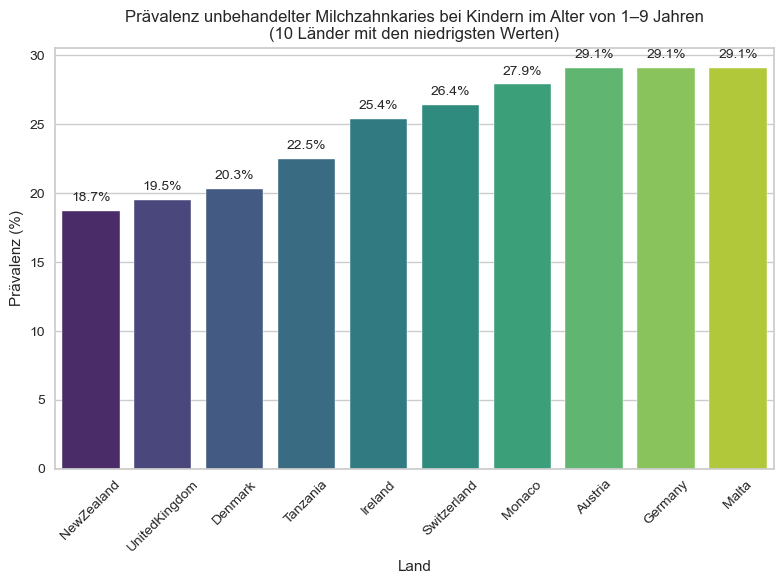

In [28]:
# Prävalenz unbehandelter Milchzahnkaries bei Kindern im Alter von 1–9 Jahren – 10 Länder mit den niedrigsten Werten
low10_caries = (
    df.nsmallest(10, "UntreatedDeciduousCaries1_9Rate")
      .sort_values("UntreatedDeciduousCaries1_9Rate")
)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Farbpalette definieren
colors = sns.color_palette("viridis", len(low10_caries))

ax = sns.barplot(
    x="Location",
    y="UntreatedDeciduousCaries1_9Rate",
    data=low10_caries,
    palette=colors
)

# Prozentwerte über den Balken anzeigen
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Prävalenz unbehandelter Milchzahnkaries bei Kindern im Alter von 1–9 Jahren\n(10 Länder mit den niedrigsten Werten)",
    fontsize=12
)
plt.xlabel("Land")
plt.ylabel("Prävalenz (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


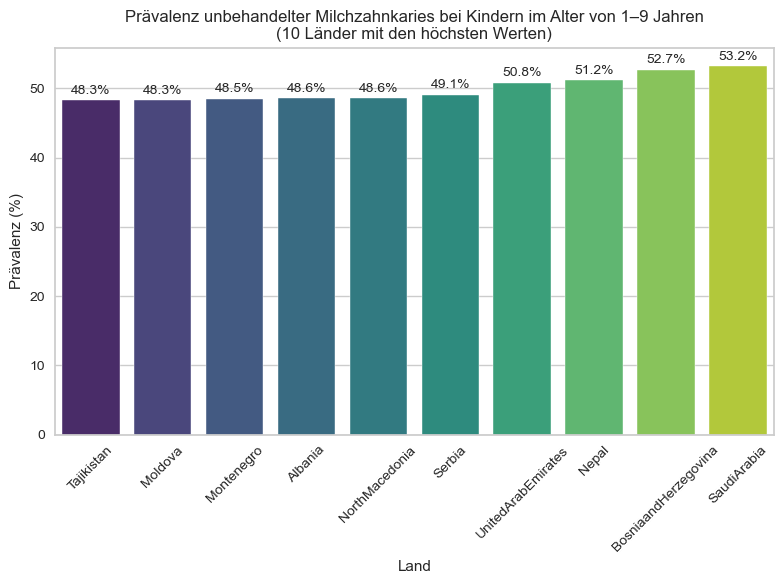

In [29]:
# Prävalenz unbehandelter Milchzahnkaries bei Kindern im Alter von 1–9 Jahren – 10 Länder mit den höchsten Werten
high10_caries = (
    df.nlargest(10, "UntreatedDeciduousCaries1_9Rate")
      .sort_values("UntreatedDeciduousCaries1_9Rate")
)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Farbpalette definieren
colors = sns.color_palette("viridis", len(high10_caries))

ax = sns.barplot(
    x="Location",
    y="UntreatedDeciduousCaries1_9Rate",
    data=high10_caries,
    palette=colors
)

# Prozentwerte über den Balken anzeigen
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Prävalenz unbehandelter Milchzahnkaries bei Kindern im Alter von 1–9 Jahren\n(10 Länder mit den höchsten Werten)",
    fontsize=12
)
plt.xlabel("Land")
plt.ylabel("Prävalenz (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


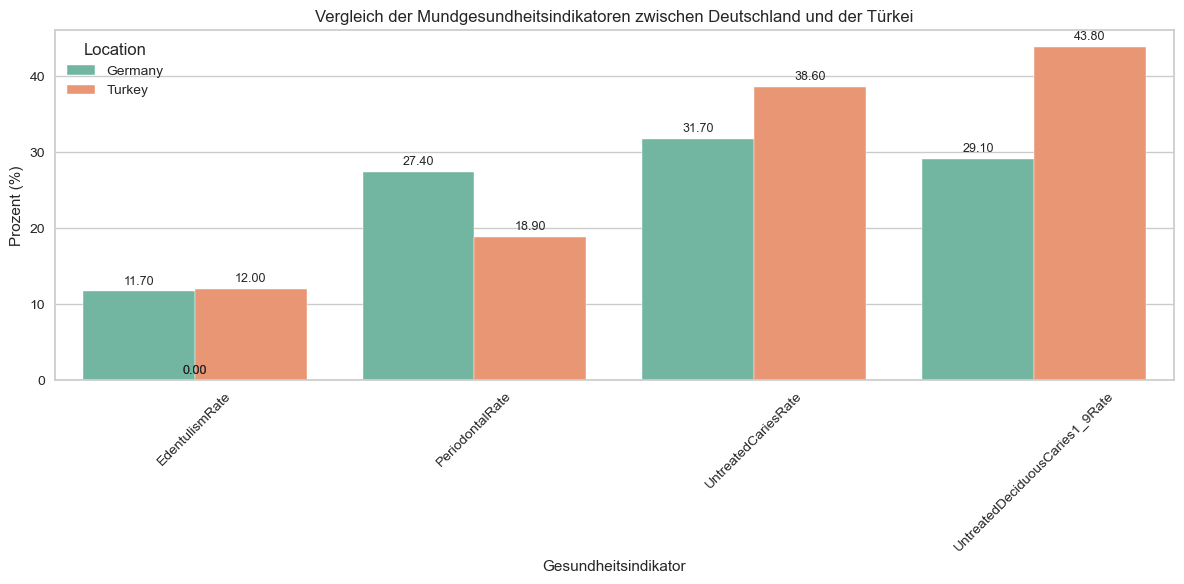

In [30]:
# Vergleich der Mundgesundheitsindikatoren: Deutschland und Türkei
countries = ["Germany", "Turkey"]
df_countries = df[df["Location"].isin(countries)]

# Relevante Mundgesundheitsindikatoren
health_cols = [
    "EdentulismRate",
    "PeriodontalRate",
    "UntreatedCariesRate",
    "UntreatedDeciduousCaries1_9Rate"
]

plt.figure(figsize=(12, 6))

# Daten ins Long-Format umwandeln
df_melted = df_countries.melt(
    id_vars=["Location"],
    value_vars=health_cols,
    var_name="HealthIndicator",
    value_name="Value"
)

ax = sns.barplot(
    x="HealthIndicator",
    y="Value",
    hue="Location",
    data=df_melted,
    palette="Set2"
)

# Werte über den Balken anzeigen
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=height + 0.5,
        s=f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Vergleich der Mundgesundheitsindikatoren zwischen Deutschland und der Türkei")
plt.xlabel("Gesundheitsindikator")
plt.ylabel("Prozent (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


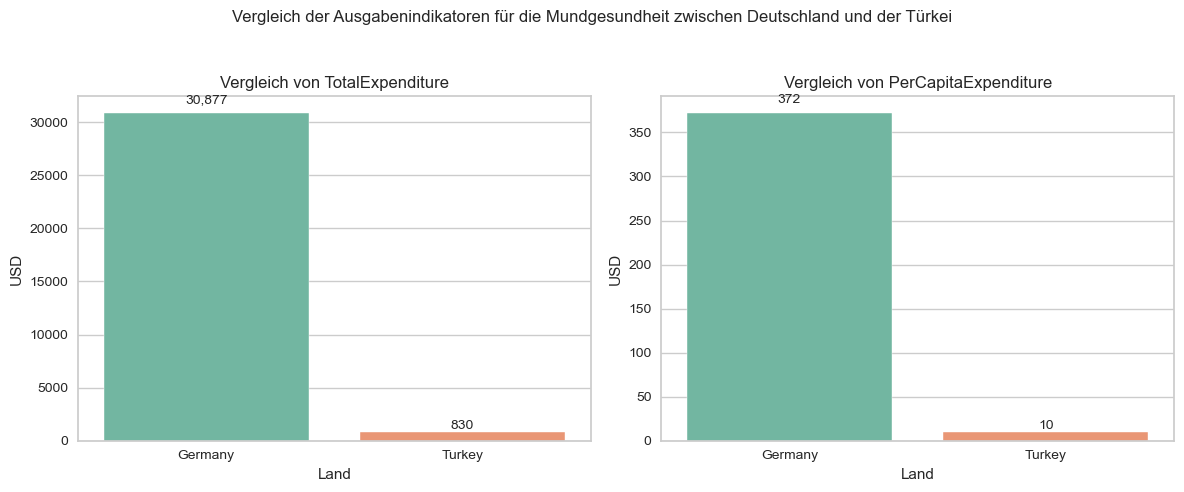

In [31]:
# Vergleich der Ausgabenindikatoren für die Mundgesundheit: Deutschland und Türkei

expenditure_cols = ["TotalExpenditure", "PerCapitaExpenditure"]

# Durchschnittliche Ausgaben nach Land berechnen
df_avg = df_countries.groupby("Location")[expenditure_cols].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(expenditure_cols):
    ax = axes[i]
    sns.barplot(
        x="Location",
        y=col,
        data=df_avg,
        ax=ax,
        palette="Set2"
    )
    
    # Werte über den Balken anzeigen
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width() / 2,
            y=height + 0.02 * height,
            s=f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10
        )
    
    ax.set_title(f"Vergleich von {col}")
    ax.set_xlabel("Land")
    ax.set_ylabel("USD")

plt.suptitle(
    "Vergleich der Ausgabenindikatoren für die Mundgesundheit zwischen Deutschland und der Türkei",
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


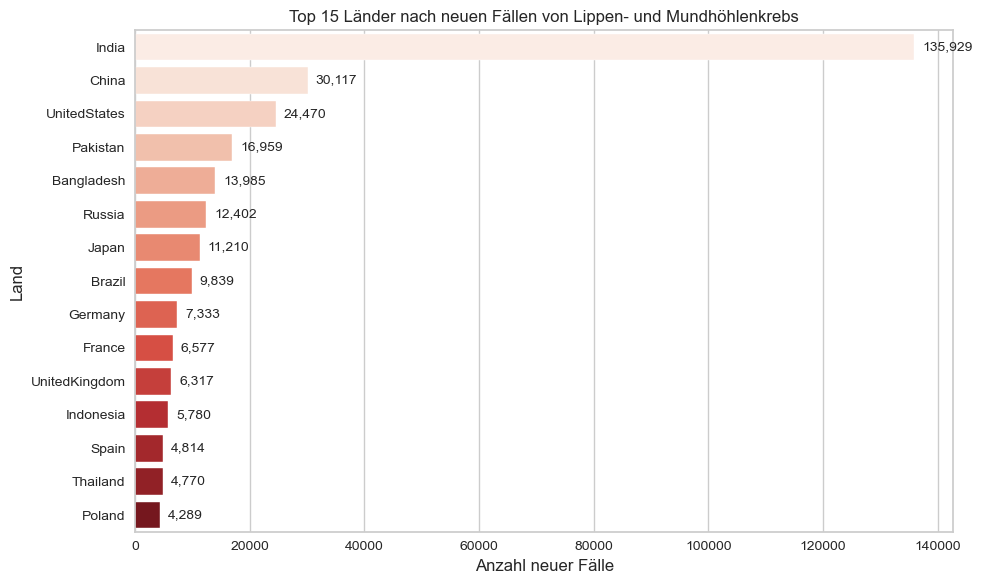

In [32]:
# Top 15 Länder nach der Anzahl neuer Fälle von Lippen- und Mundhöhlenkrebs
top15_cancer = df.nlargest(15, "TotalCancerNewCases")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x="TotalCancerNewCases",
    y="Location",
    data=top15_cancer,
    palette=sns.color_palette("Reds", n_colors=15)
)

# Fallzahlen neben den Balken anzeigen
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + (0.01 * top15_cancer["TotalCancerNewCases"].max()),
        p.get_y() + p.get_height() / 2,
        f"{int(width):,}",
        ha="left",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 15 Länder nach neuen Fällen von Lippen- und Mundhöhlenkrebs",
    fontsize=12
)
plt.xlabel("Anzahl neuer Fälle", fontsize=12)
plt.ylabel("Land", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


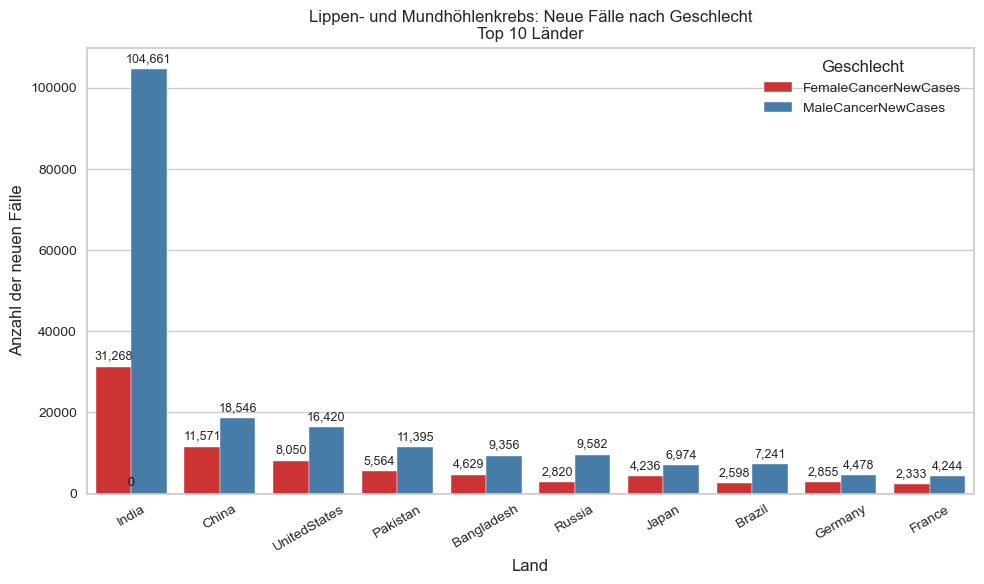

In [33]:
# Lippen- und Mundhöhlenkrebs: Neue Fälle nach Geschlecht – Top 10 Länder
top10_cancer = df.nlargest(10, "TotalCancerNewCases")

# Spalten für neue Krebsfälle nach Geschlecht
cancer_cols = ["FemaleCancerNewCases", "MaleCancerNewCases"]

# Daten ins Long-Format umwandeln
df_melted = top10_cancer.melt(
    id_vars=["Location"],
    value_vars=cancer_cols,
    var_name="Geschlecht",
    value_name="Fallzahl"
)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x="Location",
    y="Fallzahl",
    hue="Geschlecht",
    data=df_melted,
    palette="Set1"
)

# Fallzahlen über den Balken anzeigen
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + (0.01 * df_melted["Fallzahl"].max()),
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    "Lippen- und Mundhöhlenkrebs: Neue Fälle nach Geschlecht\nTop 10 Länder",
    fontsize=12
)
plt.xlabel("Land", fontsize=12)
plt.ylabel("Anzahl der neuen Fälle", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Geschlecht")
plt.tight_layout()
plt.show()


##### **Clustering mit dem K-Means-Algorithmus**


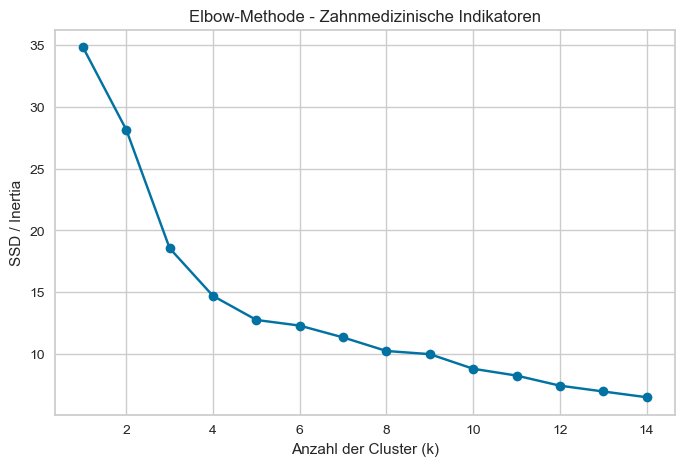

In [34]:
# K-Means-Clusteranalyse basierend auf zahnmedizinischen Indikatoren von Ländern

health_cols = ["EdentulismRate", "PeriodontalRate", "UntreatedCariesRate",
               "UntreatedDeciduousCaries1_9Rate", "ProductivityLoss"]

# Daten skalieren
scaler = MinMaxScaler()
X_health_scaled = scaler.fit_transform(df[health_cols])

# SSD für verschiedene Clusterzahlen berechnen
ssd = []
K = range(1, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_health_scaled)
    ssd.append(kmeans.inertia_)

# Elbow-Plot
plt.figure(figsize=(8,5))
plt.plot(K, ssd, 'bo-')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('SSD / Inertia')
plt.title('Elbow-Methode - Zahnmedizinische Indikatoren')
plt.show()

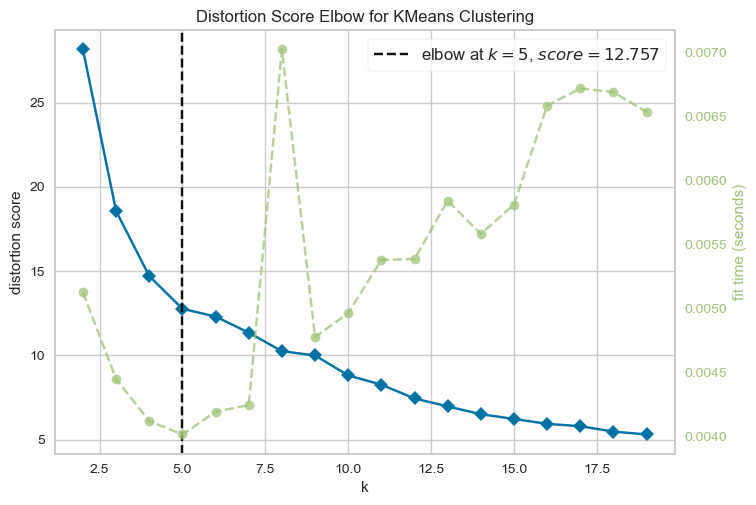

Optimale Clusteranzahl: 5


In [35]:
# Optimale Clusteranzahl
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[health_cols])

kmeans = KMeans(random_state=42)

elbow = KElbowVisualizer(kmeans, k=(2,20))
elbow.fit(X_scaled) 
elbow.show()

print("Optimale Clusteranzahl:", elbow.elbow_value_)


In [36]:
scaler = MinMaxScaler()
X_health_scaled = scaler.fit_transform(df[health_cols])

kmeans = KMeans(n_clusters=elbow.elbow_value_, random_state=42)
kmeans.fit(X_health_scaled)

print("Anzahl der Cluster:", kmeans.n_clusters)

print("Cluster-Zentren:\n", kmeans.cluster_centers_)

df["kmeans_cluster_no"] = kmeans.labels_ + 1

df.head()

Anzahl der Cluster: 5
Cluster-Zentren:
 [[0.38286713 0.61400058 0.30344203 0.714361   0.04516839]
 [0.29487179 0.17775468 0.39385037 0.76788092 0.00375052]
 [0.09722222 0.70474664 0.29408213 0.61297447 0.00336623]
 [0.6811491  0.56813865 0.36486849 0.3324745  0.04997081]
 [0.69261294 0.49496337 0.5218254  0.8005521  0.01179283]]


,Location,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases,ExpenditureGroup,kmeans_cluster_no
0,Angola,70.2,2.3,4.0,23.9,27.2,37.8,195.8,482.0,166.0,316.0,Medium,3
1,Burundi,1.3,0.1,2.0,19.2,31.7,41.6,5.3,92.0,30.0,62.0,Low,3
2,Benin,3.3,0.3,2.9,27.1,29.5,39.6,30.0,74.0,42.0,32.0,Low,3
3,BurkinaFaso,4.6,0.2,1.9,27.4,27.5,40.3,30.8,179.0,55.0,124.0,Low,3
4,Botswana,57.4,24.1,7.5,26.3,32.7,37.6,59.2,60.0,8.0,52.0,Medium,1


In [37]:
# Statistische Zusammenfassung der Ländergruppen nach K-means-Clustern
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if "kmeans_cluster_no" in numeric_cols:
    numeric_cols.remove("kmeans_cluster_no")

summary = df.groupby("kmeans_cluster_no")[numeric_cols].agg(["count","mean","median"])

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]

summary = summary.round(1)

summary


,TotalExpenditure_count,TotalExpenditure_mean,TotalExpenditure_median,PerCapitaExpenditure_count,PerCapitaExpenditure_mean,PerCapitaExpenditure_median,EdentulismRate_count,EdentulismRate_mean,EdentulismRate_median,PeriodontalRate_count,...,ProductivityLoss_median,TotalCancerNewCases_count,TotalCancerNewCases_mean,TotalCancerNewCases_median,FemaleCancerNewCases_count,FemaleCancerNewCases_mean,FemaleCancerNewCases_median,MaleCancerNewCases_count,MaleCancerNewCases_mean,MaleCancerNewCases_median
kmeans_cluster_no,,,,,,,,,,,,,,,,,,,,,
1,44,5202.2,62.0,44,57.6,23.7,44,7.2,7.4,44,...,118.7,38,2091.1,92.5,38,782.9,32.0,38,1308.2,53.5
2,37,288.9,6.9,37,11.6,3.5,37,5.8,6.0,37,...,37.0,29,739.1,277.0,29,255.8,138.0,29,483.4,126.0
3,42,10.8,2.9,42,0.6,0.2,42,2.7,2.8,42,...,26.0,41,4280.6,166.0,41,1100.7,55.0,41,3180.0,74.0
4,27,4781.9,826.5,27,225.4,195.4,27,11.8,11.7,27,...,1384.4,24,1947.9,584.0,24,738.8,199.0,24,1209.2,354.0
5,42,427.1,123.6,42,35.0,15.8,42,12.0,12.0,42,...,312.5,42,1106.8,261.5,42,298.7,101.5,42,808.1,178.0


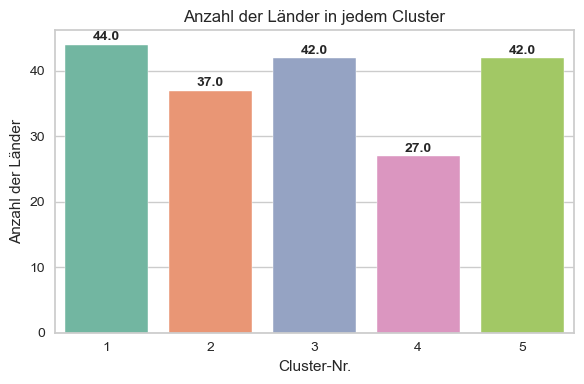

In [38]:
# Anzahl der Länder in den Ländergruppen
plt.figure(figsize=(6,4))
ax = sns.countplot(x='kmeans_cluster_no', data=df, palette='Set2')

for p in ax.patches:
    count = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,  
        count + 0.2,                  
        str(count),                   
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Anzahl der Länder in jedem Cluster")
plt.xlabel("Cluster-Nr.")
plt.ylabel("Anzahl der Länder")
plt.tight_layout()
plt.show()


In [39]:
# Länder pro Cluster
cluster_countries = df.groupby("kmeans_cluster_no")["Location"].apply(list)
cluster_countries

kmeans_cluster_no
1    [Botswana, CentralAfricanRepublic, Lesotho, Es...
2    [Mauritius, SierraLeone, Seychelles, Afghanist...
3    [Angola, Burundi, Benin, BurkinaFaso, Coted'Iv...
4    [Namibia, Colombia, TrinidadandTobago, Andorra...
5    [Algeria, Bolivia, Brazil, Chile, Cuba, Ecuado...
Name: Location, dtype: object

In [40]:
# Durchschnittswerte pro Cluster
cluster_means = df.groupby("kmeans_cluster_no")[numeric_cols].mean()
cluster_means

,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases
kmeans_cluster_no,,,,,,,,,,
1,5202.229545,57.565909,7.172727,21.456818,30.275000,43.345455,3544.390909,2091.105263,782.894737,1308.210526
2,288.929730,11.605405,5.800000,7.845946,32.770270,45.191892,294.397297,739.137931,255.758621,483.379310
3,10.807143,0.602381,2.716667,24.288095,30.016667,39.847619,264.242857,4280.609756,1100.658537,3179.951220
4,4781.881481,225.388889,11.825926,20.025926,31.970370,30.170370,3921.229630,1947.916667,738.750000,1209.166667
5,427.126190,35.033333,12.004762,17.742857,36.302381,46.319048,925.464286,1106.809524,298.714286,808.095238


In [41]:
# Länderliste nach Clustern
clusters_countries = df.groupby("kmeans_cluster_no")["Location"].apply(list)

for cluster, countries in clusters_countries.items():
    print(f"\n # Cluster {cluster} ({len(countries)} Länder):")
    print(", ".join(countries))


 # Cluster 1 (44 Länder):
Botswana, CentralAfricanRepublic, Lesotho, Eswatini, SouthAfrica, Zimbabwe, Argentina, AntiguaandBarbuda, Bahamas, Belize, Barbados, Canada, CostaRica, Dominica, DominicanRepublic, Grenada, Guatemala, Guyana, Honduras, Haiti, Jamaica, SaintKittsandNevis, SaintLucia, Mexico, Nicaragua, Panama, Paraguay, ElSalvador, Suriname, UnitedStates, SaintVincentandtheGrenadines, Venezuela, UnitedArabEmirates, Bahrain, Egypt, Iran, Kuwait, Libya, Qatar, Indonesia, Thailand, China, SouthKorea, Singapore

 # Cluster 2 (37 Länder):
Mauritius, SierraLeone, Seychelles, Afghanistan, Iraq, Jordan, Oman, SaudiArabia, Sudan, Yemen, Spain, Tajikistan, Uzbekistan, SriLanka, Maldives, Myanmar, Nepal, NorthKorea, Timor-Leste, Brunei, Fiji, Micronesia, Cambodia, Kiribati, Laos, MarshallIslands, Malaysia, Nauru, Philippines, Palau, PapuaNewGuinea, SolomonIslands, Tonga, Tuvalu, Vietnam, Vanuatu, Samoa

 # Cluster 3 (42 Länder):
Angola, Burundi, Benin, BurkinaFaso, Coted'Ivoire, Cameroon

Cluster 1 (44 Länder)

Länder: Südliches Afrika (Botswana, Südafrika, Simbabwe), einige Länder Nordafrikas (Ägypten, Libyen), Nordamerika (USA, Kanada, Mexiko), Mittelamerika und Karibik (Dominikanische Republik, Jamaika, viele Inselstaaten außer Kuba), Südamerika (Argentinien, Venezuela, Paraguay), Asien (China, Korea, Indonesien, Thailand, Singapur), Golfstaaten (VAE, Katar, Kuwait, Bahrain).

Allgemeine Merkmale:

Hohe Gesundheitsausgaben, vergleichsweise gute Mundgesundheit, starke Wirtschaft und Gesundheitsinfrastruktur.

Länder mit hohem Einkommen wie USA, Kanada, Singapur, China sowie einige ölreiche Länder im Nahen Osten fallen in denselben Cluster (gemischte Struktur).

Cluster 1 (USA, China, Golfstaaten usw.)

Sehr hohe Gesundheitsausgaben (insgesamt 5.202 Mio. USD), aber pro Kopf relativ niedrig (57,6 USD) → große Bevölkerungen (China, USA).

Mundgesundheit auf mittlerem Niveau (Edentulismus 7,1 %).

Gesamtzahl der Krebsfälle hoch (2.091).

Cluster 2 (37 Länder)

Länder: Südasien (Afghanistan, Nepal, Sri Lanka), Zentralasien (Tadschikistan, Usbekistan), Naher Osten (Irak, Jemen, Saudi-Arabien), Südostasien und Pazifikländer (Malaysia, Philippinen, Fidschi, Vietnam).

Allgemeine Merkmale:

Mittleres Einkommensniveau, Gesundheitsindikatoren und Ausgaben auf mittlerem Niveau.

Gesundheitssysteme befinden sich in der Entwicklung, jedoch bestehen regionale Ungleichheiten.

Cluster 2 (Naher Osten + Pazifik + Entwicklungsländer Asiens)

Niedrige Ausgaben (insgesamt 289 Mio. USD, pro Kopf 11,6 USD).

Mundgesundheit relativ gut (Edentulismus 5,8 %, Parodontal 7,8 %).

Gesamtzahl der Krebsfälle niedrig (739).

Cluster 3 (42 Länder)

Länder: Großteils afrikanische Länder (Kenia, Nigeria, Tansania, Äthiopien, Senegal usw.), außerdem Pakistan, Indien, Bangladesch, Bhutan.

Allgemeine Merkmale:

Niedrige Gesundheitsausgaben, höhere Probleme mit der Mundgesundheit.

Entwicklungsländer und Länder mit niedrigem Einkommen.

Dies ist die verletzlichste Gruppe.

Cluster 3 (Afrika + Indien, Pakistan)

Sehr niedrige Ausgaben (insgesamt 10,8 Mio. USD, pro Kopf 0,6 USD).

Edentulismus niedrig (2,7 %), könnte jedoch an unzureichenden Gesundheitsdiensten liegen (nicht gemeldete Fälle möglich).

Parodontaler Erkrankungsgrad sehr hoch (24 %) → ernsthafte Probleme.

Gesamtzahl der Krebsfälle sehr hoch (4.280, bei Männern 3.180) → geringer Zugang zu Gesundheitsdiensten.

Cluster 4 (27 Länder)

Länder: Europäische Union und Westeuropa (Deutschland, Frankreich, Italien, skandinavische Länder, Benelux), außerdem Australien, Japan und Neuseeland.

Allgemeine Merkmale:

Dieser Cluster zeichnet sich durch wohlhabende OECD-Länder aus.

Gesundheitssysteme sehr entwickelt und Pro-Kopf-Gesundheitsausgaben sehr hoch (insgesamt 4.781 Mio. USD, pro Kopf 225 USD).

Mundgesundheitsindikatoren insgesamt gut, jedoch ist Edentulismus (Zahnverlust) mit 11,8 % am höchsten; dies hängt größtenteils mit der älteren Bevölkerung zusammen.

Gesamtzahl der Krebsfälle auf mittlerem Niveau (1.947 Fälle).

Fazit: Trotz eines starken Gesundheitssystems und hoher Ausgaben sind altersbedingte Probleme der Mundgesundheit in diesen Ländern stärker ausgeprägt.

Cluster 5 (42 Länder)

Länder: Osteuropa (Russland, Ukraine, Polen, Rumänien, Balkanstaaten), Nordafrika (Algerien, Tunesien, Marokko), Lateinamerika (Brasilien, Chile, Peru, Uruguay), Türkei, Israel, Schweden, Kasachstan.

Allgemeine Merkmale:

Mittlere bis hohe Ausgabenniveaus, Mundgesundheit in einigen Bereichen gut, aber nicht so gut wie in westlichen Ländern.

Übergangswirtschaften und Länder mit „mittlerem bis hohem Einkommen“.

Cluster 5 (Osteuropa + Lateinamerika + Türkei)

Mittlere Ausgaben (insgesamt 427 Mio. USD, pro Kopf 35 USD).

Edentulismus hoch (12 %) → schwache Mundgesundheit.

Parodontal- und Kariesraten hoch.

Gesamtzahl der Krebsfälle mittel (1.106).

Cluster-Zusammenfassung nach Entwicklungsstand:

Cluster 3: Niedrigste Entwicklung (Afrika + Südasien)

Cluster 2: Mittlere Entwicklung (Naher Osten + Südostasien + Pazifik)

Cluster 5: Mittelhohe Entwicklung (Osteuropa + Lateinamerika + Türkei)

Cluster 1: Hohe Entwicklung (USA, Kanada, China, ölreiche Länder im Nahen Osten, einige Länder Lateinamerikas)

Cluster 4: Höchste Entwicklung (Westeuropa + OECD-Länder)

Zusätzliche Klassifikationen:

Ärmster Cluster: Cluster 3 (Afrika + Südasien)

Reichster Cluster: Cluster 4 (OECD-Länder)

Übergangsländer: Cluster 5 (Osteuropa, Türkei, Lateinamerika)

Spezielle gemischte Gruppe: Cluster 1 (USA, China, ölreiche Länder)

Mittlere Entwicklung: Cluster 2 (Naher Osten + Pazifikländer)


Vergleich:
                                  Deutschland  Cluster_Durchschnitt
TotalExpenditure                     30877.3                4781.9
PerCapitaExpenditure                   372.2                 225.4
EdentulismRate                          11.7                  11.8
PeriodontalRate                         27.4                  20.0
UntreatedCariesRate                     31.7                  32.0
UntreatedDeciduousCaries1_9Rate         29.1                  30.2
ProductivityLoss                     19395.9                3921.2
TotalCancerNewCases                   7333.0                1947.9
FemaleCancerNewCases                  2855.0                 738.8
MaleCancerNewCases                    4478.0                1209.2


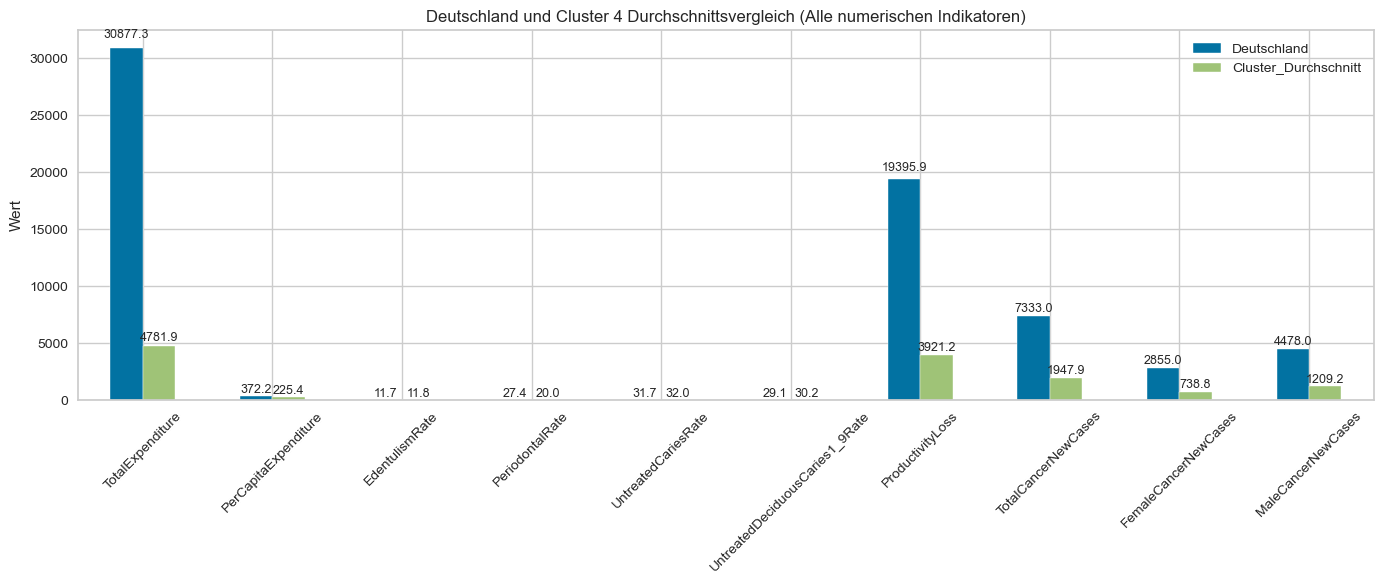

In [42]:
# Deutschland und Cluster 4 Durchschnittsvergleich
numerical_cols = df.select_dtypes(include="number").columns.tolist()
numerical_cols.remove("kmeans_cluster_no")  

germany_values = df[df["Location"] == "Germany"][numerical_cols]

germany_cluster = df[df["Location"] == "Germany"]["kmeans_cluster_no"].values[0]

cluster_mean = df[df["kmeans_cluster_no"] == germany_cluster][numerical_cols].mean()

comparison = pd.DataFrame({
    "Deutschland": germany_values.values.flatten(),
    "Cluster_Durchschnitt": cluster_mean.values
}, index=numerical_cols).round(1)

print("\nVergleich:\n", comparison)

ax = comparison.plot(kind="bar", figsize=(14,6))

for p in ax.patches:
    height = p.get_height()
    ax.text(x=p.get_x() + p.get_width()/2., 
            y=height + 0.02*height,
            s=f'{height:.1f}',
            ha='center', va='bottom', fontsize=9)

plt.title(f"Deutschland und Cluster {germany_cluster} Durchschnittsvergleich (Alle numerischen Indikatoren)")
plt.ylabel("Wert")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


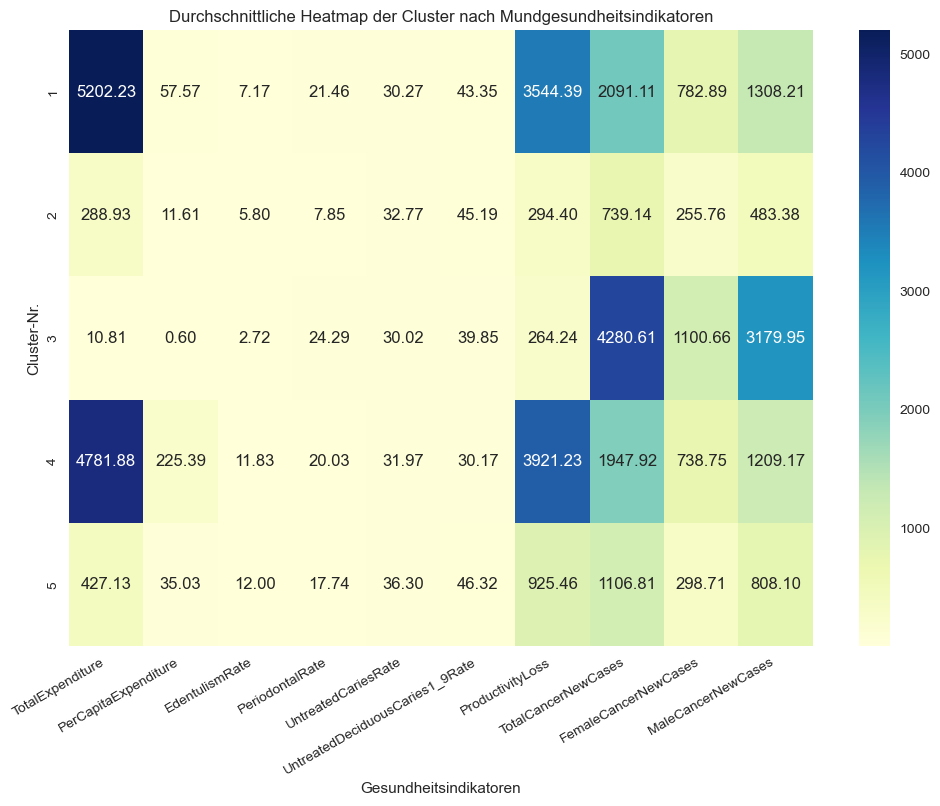

In [43]:
# Durchschnittliche Heatmap der Cluster nach Mundgesundheitsindikatoren
num_cols = df.select_dtypes(include='number').columns.drop('kmeans_cluster_no')

# Durchschnittswerte pro Cluster
cluster_means_health = df.groupby("kmeans_cluster_no")[num_cols].mean()

# Heatmap-Visualisierung
plt.figure(figsize=(12,8))
sns.heatmap(cluster_means_health, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Durchschnittliche Heatmap der Cluster nach Mundgesundheitsindikatoren")
plt.xticks(rotation=30, ha='right')  
plt.xlabel("Gesundheitsindikatoren")
plt.ylabel("Cluster-Nr.")
plt.show()

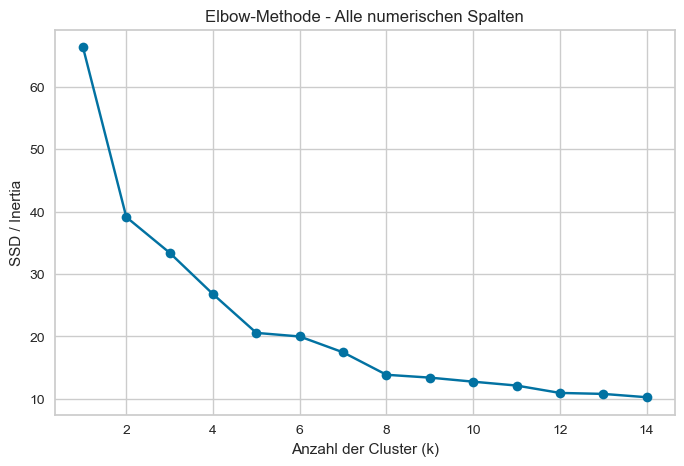

In [44]:
# K-Means-Clustering mit allen numerischen Indikatoren einschließlich Mundkrebs (fehlende Werte entfernt)

numeric_cols = df.select_dtypes(include=np.number).columns

df_numeric = df[numeric_cols].dropna()

scaler = MinMaxScaler()
Xall_scaled = scaler.fit_transform(df_numeric)

ssd = []
K = range(1, 15)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(Xall_scaled)
    ssd.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, ssd, 'bo-')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('SSD / Inertia')
plt.title('Elbow-Methode - Alle numerischen Spalten')
plt.show()


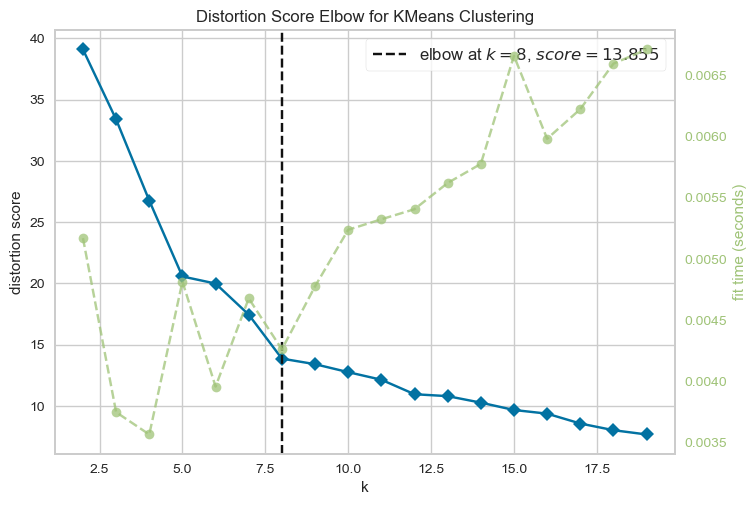

Optimale Clusteranzahl: 8


In [45]:
# Optimale Anzahl der Cluster
scaler = MinMaxScaler()
Xall_scaled = scaler.fit_transform(df_numeric)

kmeans = KMeans(random_state=42)

elbow = KElbowVisualizer(kmeans, k=(2,20))
elbow.fit(Xall_scaled)
elbow.show()

print("Optimale Clusteranzahl:", elbow.elbow_value_)

In [46]:
scaler = MinMaxScaler()
Xall_scaled = scaler.fit_transform(df_numeric)

kmeans = KMeans(n_clusters=elbow.elbow_value_, random_state=42)
kmeans.fit(Xall_scaled)

print("Anzahl der Cluster:", kmeans.n_clusters)

print("Cluster-Zentren:\n", kmeans.cluster_centers_)

df_numeric["kmeans_cluster_no"] = kmeans.labels_ + 1

df_numeric.head()

Anzahl der Cluster: 8
Cluster-Zentren:
 [[1.93069454e-02 1.00896002e-01 3.76992377e-01 6.03170478e-01
  3.09341951e-01 7.06071289e-01 2.66587528e-02 1.09196133e-02
  1.87567637e-02 8.58765320e-03 1.11022302e-16]
 [1.62761583e-02 1.78466319e-01 6.67652860e-01 5.13313609e-01
  3.96599777e-01 3.30434783e-01 3.12985874e-02 9.56225938e-03
  1.56857342e-02 7.74228638e-03 7.69230769e-01]
 [7.28994546e-05 1.19926199e-03 9.48717949e-02 7.02884615e-01
  2.95108696e-01 6.11086957e-01 1.20445845e-03 7.26419328e-03
  1.10808174e-02 6.13343207e-03 5.00000000e-01]
 [2.75992142e-03 2.26692830e-02 2.88019452e-01 2.10764810e-01
  3.76436782e-01 7.57921039e-01 4.76173275e-03 5.42304274e-03
  8.17956443e-03 4.60901309e-03 2.50000000e-01]
 [2.38497129e-03 4.57661682e-02 6.95512821e-01 4.94551282e-01
  5.23097826e-01 8.11666667e-01 1.12264359e-02 8.37122132e-03
  9.67522707e-03 7.99111408e-03 1.00000000e+00]
 [6.10802619e-02 6.18551773e-01 7.01183432e-01 6.07248521e-01
  3.55351171e-01 3.81716834e-01 7.5891

,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases,kmeans_cluster_no
0,70.2,2.3,4.0,23.9,27.2,37.8,195.8,482.0,166.0,316.0,3
1,1.3,0.1,2.0,19.2,31.7,41.6,5.3,92.0,30.0,62.0,3
2,3.3,0.3,2.9,27.1,29.5,39.6,30.0,74.0,42.0,32.0,3
3,4.6,0.2,1.9,27.4,27.5,40.3,30.8,179.0,55.0,124.0,3
4,57.4,24.1,7.5,26.3,32.7,37.6,59.2,60.0,8.0,52.0,1


In [47]:
# Statistische Zusammenfassung der Ländergruppen nach K-means-Clustern
numeric_cols = df_numeric.select_dtypes(include=np.number).columns.tolist()

if "kmeans_cluster_no" in numeric_cols:
    numeric_cols.remove("kmeans_cluster_no")

cluster_summary = df_numeric.groupby("kmeans_cluster_no")[numeric_cols].agg(["count", "mean", "median"])

cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]

cluster_summary = cluster_summary.round(1)

cluster_summary

,TotalExpenditure_count,TotalExpenditure_mean,TotalExpenditure_median,PerCapitaExpenditure_count,PerCapitaExpenditure_mean,PerCapitaExpenditure_median,EdentulismRate_count,EdentulismRate_mean,EdentulismRate_median,PeriodontalRate_count,...,ProductivityLoss_median,TotalCancerNewCases_count,TotalCancerNewCases_mean,TotalCancerNewCases_median,FemaleCancerNewCases_count,FemaleCancerNewCases_mean,FemaleCancerNewCases_median,MaleCancerNewCases_count,MaleCancerNewCases_mean,MaleCancerNewCases_median
kmeans_cluster_no,,,,,,,,,,,,,,,,,,,,,
1,37,2577.6,82.3,37,52.0,16.7,37,7.1,7.5,37,...,220.4,37,1486.3,89.0,37,586.5,32.0,37,899.8,53.0
2,13,2173.0,593.7,13,91.9,91.6,13,11.6,12.0,13,...,1132.8,13,1301.8,317.0,13,490.5,115.0,13,811.3,208.0
3,40,9.7,2.9,40,0.6,0.2,40,2.7,2.7,40,...,26.0,40,989.4,144.5,40,346.5,54.0,40,642.9,74.0
4,29,368.5,16.7,29,11.7,3.1,29,5.7,5.4,29,...,49.8,29,739.1,277.0,29,255.8,138.0,29,483.4,126.0
5,40,318.4,117.2,40,23.6,15.5,40,12.0,12.1,40,...,291.4,40,1139.9,261.5,40,302.5,92.5,40,837.4,178.0
6,13,8154.6,3375.8,13,318.5,321.7,13,12.1,11.7,13,...,2771.3,13,2362.9,695.0,13,907.6,331.0,13,1455.3,471.0
7,1,133505.8,133505.8,1,405.5,405.5,1,10.2,10.2,1,...,78468.5,1,24470.0,24470.0,1,8050.0,8050.0,1,16420.0,16420.0
8,1,64.5,64.5,1,0.0,0.0,1,4.0,4.0,1,...,7248.8,1,135929.0,135929.0,1,31268.0,31268.0,1,104661.0,104661.0


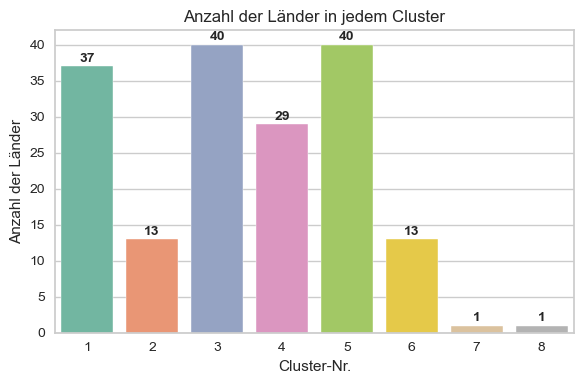

In [48]:
# Anzahl der Länder in den Ländergruppen
plt.figure(figsize=(6,4))
ax = sns.countplot(x='kmeans_cluster_no', data=df_numeric, palette='Set2')

for p in ax.patches:
    count = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,  
        count + 0.2,              
        str(int(count)),             
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.title("Anzahl der Länder in jedem Cluster")
plt.xlabel("Cluster-Nr.")
plt.ylabel("Anzahl der Länder")
plt.tight_layout()
plt.show()

In [49]:
# Durchschnittswerte pro Cluster
cluster_means = df_numeric.groupby("kmeans_cluster_no")[numeric_cols].mean()
cluster_means

,TotalExpenditure,PerCapitaExpenditure,EdentulismRate,PeriodontalRate,UntreatedCariesRate,UntreatedDeciduousCaries1_9Rate,ProductivityLoss,TotalCancerNewCases,FemaleCancerNewCases,MaleCancerNewCases
kmeans_cluster_no,,,,,,,,,,
1,2577.589189,51.951351,7.081081,21.118919,30.437838,43.059459,2093.527027,1486.270270,586.486486,899.783784
2,2172.961538,91.892308,11.615385,18.315385,32.846154,30.100000,2457.600000,1301.769231,490.461538,811.307692
3,9.732500,0.617500,2.680000,24.230000,30.045000,39.782500,96.210000,989.400000,346.475000,642.925000
4,368.465517,11.672414,5.693103,8.875862,32.289655,44.848276,375.337931,739.137931,255.758621,483.379310
5,318.407500,23.565000,12.050000,17.730000,36.337500,46.702500,882.602500,1139.875000,302.525000,837.350000
6,8154.569231,318.492308,12.138462,21.246154,31.707692,31.869231,5956.630769,2362.923077,907.615385,1455.307692
7,133505.800000,405.500000,10.200000,15.700000,24.300000,42.600000,78468.500000,24470.000000,8050.000000,16420.000000
8,64.500000,0.000000,4.000000,21.800000,28.800000,43.300000,7248.800000,135929.000000,31268.000000,104661.000000


In [50]:
# Länderliste nach Clustern
# Falls df_numeric nur numerische Daten enthält
df_numeric["Location"] = df["Location"]
clusters_countries = df_numeric.groupby("kmeans_cluster_no")["Location"].apply(list)

for cluster, countries in clusters_countries.items():
    print(f"\n # Cluster {cluster} ({len(countries)} Länder):")
    print(", ".join(countries))


 # Cluster 1 (37 Länder):
Botswana, CentralAfricanRepublic, Lesotho, Eswatini, SouthAfrica, Zimbabwe, Argentina, Bahamas, Barbados, Canada, CostaRica, DominicanRepublic, Guatemala, Guyana, Honduras, Haiti, Jamaica, SaintLucia, Mexico, Nicaragua, Panama, Paraguay, ElSalvador, Suriname, Venezuela, UnitedArabEmirates, Bahrain, Egypt, Iran, Kuwait, Libya, Qatar, Indonesia, Thailand, China, SouthKorea, Singapore

 # Cluster 2 (13 Länder):
Namibia, Colombia, TrinidadandTobago, Cyprus, Finland, France, UnitedKingdom, Greece, Ireland, Israel, Malta, Portugal, NewZealand

 # Cluster 3 (40 Länder):
Angola, Burundi, Benin, BurkinaFaso, Coted'Ivoire, Cameroon, DemocraticRepublicoftheCongo, Congo, Comoros, CaboVerde, Eritrea, Ethiopia, Gabon, Ghana, Guinea, Gambia, Guinea-Bissau, EquatorialGuinea, Kenya, Liberia, Madagascar, Mali, Mozambique, Mauritania, Malawi, Niger, Nigeria, Rwanda, Senegal, SouthSudan, Chad, Togo, Tanzania, Uganda, Zambia, Djibouti, Pakistan, Somalia, Bangladesh, Bhutan

 # Cl

Cluster 1 (37 Länder)

Mehrheitlich afrikanische Länder und einige Länder Mittelamerikas.

Gesamtausgaben und Pro-Kopf-Ausgaben tendenziell mittel-niedrig.

Durchschnittliche Gesamtausgaben: 2.577 Mio. USD

Pro-Kopf-Ausgaben: 51,95 USD

Produktivitätsverlust und Mundgesundheitsindikatoren: mittleres Niveau

Mundkrebsfälle: niedrig bis mittel

Dieser Cluster besteht wahrscheinlich überwiegend aus Ländern mit mittlerem Einkommen.

Cluster 2 (13 Länder)

Einige wohlhabendere europäische Länder (Schweiz, Finnland, Großbritannien usw.)

Hohe Mundgesundheitsindikatoren und höhere durchschnittliche Ausgaben.

Durchschnittliche Gesamtausgaben: 2.172 Mio. USD

Pro-Kopf-Ausgaben: 91,9 USD (höher als Cluster 1)

Mundgesundheitsindikatoren hoch

Mundkrebsfälle: mittleres Niveau

Sieht aus wie europäische Länder mit mittelhohem bis hohem Wohlstand.

Cluster 3 (40 Länder)

Vorwiegend Länder mit niedrigem Einkommen in Afrika.

Probleme bei den Mundgesundheitsindikatoren, niedrige Ausgaben.

Gesamtausgaben sehr niedrig: 9,7 Mio. USD

Pro-Kopf-Ausgaben: 0,6 USD → sehr niedriges Einkommen

Mundgesundheitsindikatoren nicht unbedingt schlecht, aber die niedrigen Ausgaben sind auffällig

Mundkrebsfälle niedrig → könnte durch demografische Faktoren oder unvollständige Berichterstattung bedingt sein

Cluster 4 (29 Länder)

Länder des Nahen Ostens und Südostasiens, gemischte Entwicklungsländer.

Ausgaben und Gesundheitsindikatoren gemischt.

Cluster 5 (40 Länder)

Vorwiegend Länder in Südamerika und Osteuropa.

Mittlere Ausgaben und Gesundheitsindikatoren.

(Cluster 4 und Cluster 5: mittlere Gesamtausgaben und Pro-Kopf-Ausgaben, Mundgesundheit und Krebsfälle variabel)

Wahrscheinlich Entwicklungsländer oder Länder mit gemischtem Einkommensniveau.

Cluster 6 (13 Länder)

Wohlhabende Länder wie Deutschland, Schweden, Österreich + andere entwickelte Länder.

Hohe Gesamt- und Pro-Kopf-Ausgaben, gute Mundgesundheitsindikatoren.

Gesamt- und Pro-Kopf-Ausgaben hoch (8.154 Mio. USD insgesamt, 318 USD pro Kopf)

Mundkrebsfälle mittel bis hoch

Länder mit hohem Wohlstandsniveau

Cluster 7 (1 Land)

Die USA bilden einen eigenen Cluster.

Gesamt- und Pro-Kopf-Ausgaben sehr hoch.

Mundkrebsfälle ebenfalls sehr hoch.

Große Gesamtausgaben, aber pro Kopf kann die Ausgaben variieren.

Die Bildung eines eigenen Clusters hängt mit der Bevölkerung und den Ausgaben zusammen.

Cluster 8 (1 Land)

Indien bildet einen eigenen Cluster.

Aufgrund der sehr großen Bevölkerung und der niedrigen Pro-Kopf-Ausgaben ein separater Cluster.

Gesamtausgaben niedrig, Pro-Kopf-Ausgaben sehr niedrig.

Mundkrebsfälle aufgrund der Bevölkerungsgröße sehr hoch.

Auch hier wirkt die große Bevölkerung und die niedrigen Pro-Kopf-Ausgaben.


Analyse-Kommentare

Das Clustering scheint Einkommen, Gesundheitsindikatoren und geographische Verteilung zu kombinieren.

Cluster 6, einschließlich Deutschland, repräsentiert wohlhabende Länder mit hohen Ausgaben und guten Gesundheitsindikatoren.

Cluster 1 und 3 repräsentieren Länder mit niedrigem Einkommen und schwachen Gesundheitsindikatoren.

Länder mit sehr starkem Bevölkerungseinfluss, wie die USA und Indien, bilden jeweils einen eigenen Cluster.

Allgemeine Kommentare

Ausgaben und Gesundheitsindikatoren sind starke Einflussfaktoren für die Clusterbildung.

Der Bevölkerungseinfluss (USA, Indien) führt zu einzelnen Clustern.

Europa und wohlhabende Länder gruppieren sich in eigenen kleinen Clustern (Cluster 6).

Länder mit niedrigem Einkommen in Afrika und einigen asiatischen Ländern gruppieren sich in Cluster 3.


Vergleich:
                                  Deutschland  Cluster_Durchschnitt
TotalExpenditure                     30877.3                8154.6
PerCapitaExpenditure                   372.2                 318.5
EdentulismRate                          11.7                  12.1
PeriodontalRate                         27.4                  21.2
UntreatedCariesRate                     31.7                  31.7
UntreatedDeciduousCaries1_9Rate         29.1                  31.9
ProductivityLoss                     19395.9                5956.6
TotalCancerNewCases                   7333.0                2362.9
FemaleCancerNewCases                  2855.0                 907.6
MaleCancerNewCases                    4478.0                1455.3


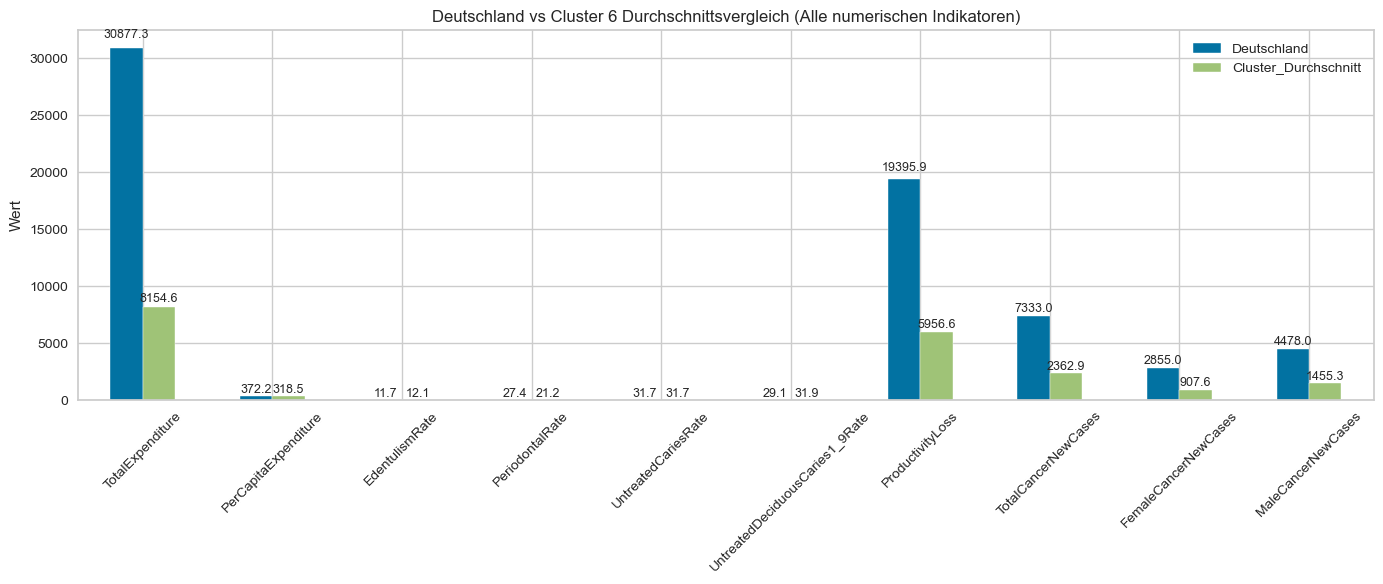

In [51]:
# Deutschland vs Cluster 6 Durchschnittsvergleich

numerical_cols = df_numeric.select_dtypes(include="number").columns.tolist()
numerical_cols.remove("kmeans_cluster_no")  # Cluster-Label nicht in den Vergleich einbeziehen

germany_values = df_numeric[df_numeric["Location"] == "Germany"][numerical_cols]

germany_cluster = df_numeric[df_numeric["Location"] == "Germany"]["kmeans_cluster_no"].values[0]

cluster_mean = df_numeric[df_numeric["kmeans_cluster_no"] == germany_cluster][numerical_cols].mean()

comparison = pd.DataFrame({
    "Deutschland": germany_values.values.flatten(),
    "Cluster_Durchschnitt": cluster_mean.values
}, index=numerical_cols).round(1)

print("\nVergleich:\n", comparison)

ax = comparison.plot(kind="bar", figsize=(14,6))

for p in ax.patches:
    height = p.get_height()
    ax.text(x=p.get_x() + p.get_width()/2., 
            y=height + 0.02*height,
            s=f'{height:.1f}',     
            ha='center', va='bottom', fontsize=9)

plt.title(f"Deutschland vs Cluster {germany_cluster} Durchschnittsvergleich (Alle numerischen Indikatoren)")
plt.ylabel("Wert")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


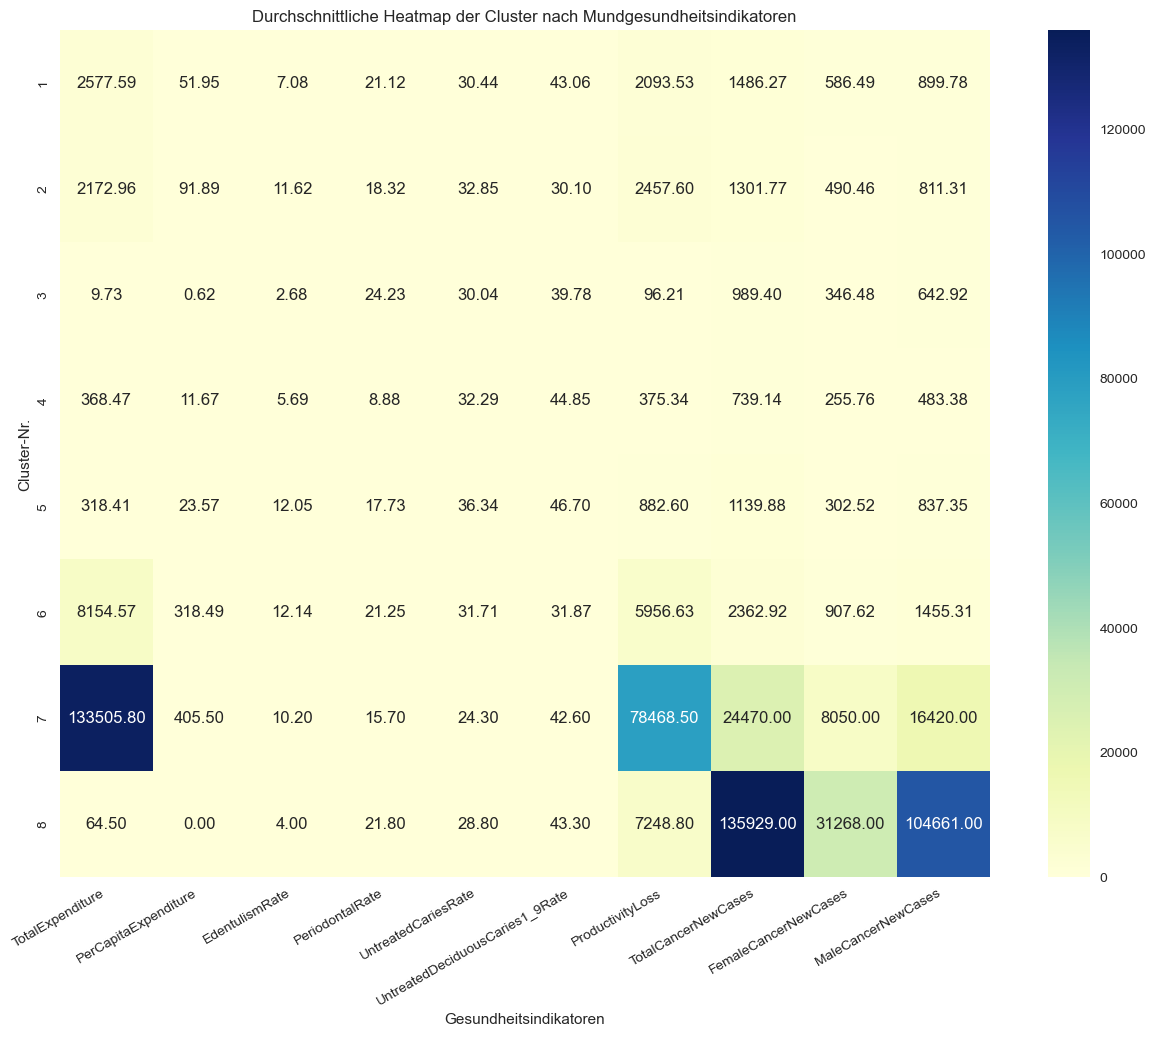

In [52]:
# Durchschnittliche Heatmap der Cluster nach Mundgesundheitsindikatoren
numeric_cols = df_numeric.select_dtypes(include='number').columns.drop('kmeans_cluster_no')

# Durchschnittswerte pro Cluster
cluster_means = df_numeric.groupby("kmeans_cluster_no")[numeric_cols].mean()

# Heatmap-Visualisierung
plt.figure(figsize=(15,11))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Durchschnittliche Heatmap der Cluster nach Mundgesundheitsindikatoren")
plt.xlabel("Gesundheitsindikatoren")
plt.ylabel("Cluster-Nr.")
plt.xticks(rotation=30, ha='right')  
plt.show()

##### **Hierarchische Clusteranalyse** 

Cophenetische Korrelation: 0.602
n_clusters=2, Silhouette Score=0.806
n_clusters=3, Silhouette Score=0.773
n_clusters=4, Silhouette Score=0.384
n_clusters=5, Silhouette Score=0.270
n_clusters=6, Silhouette Score=0.286
n_clusters=7, Silhouette Score=0.280
n_clusters=8, Silhouette Score=0.277
n_clusters=9, Silhouette Score=0.215
Optimale Clusteranzahl: 2, Silhouette Score: 0.806


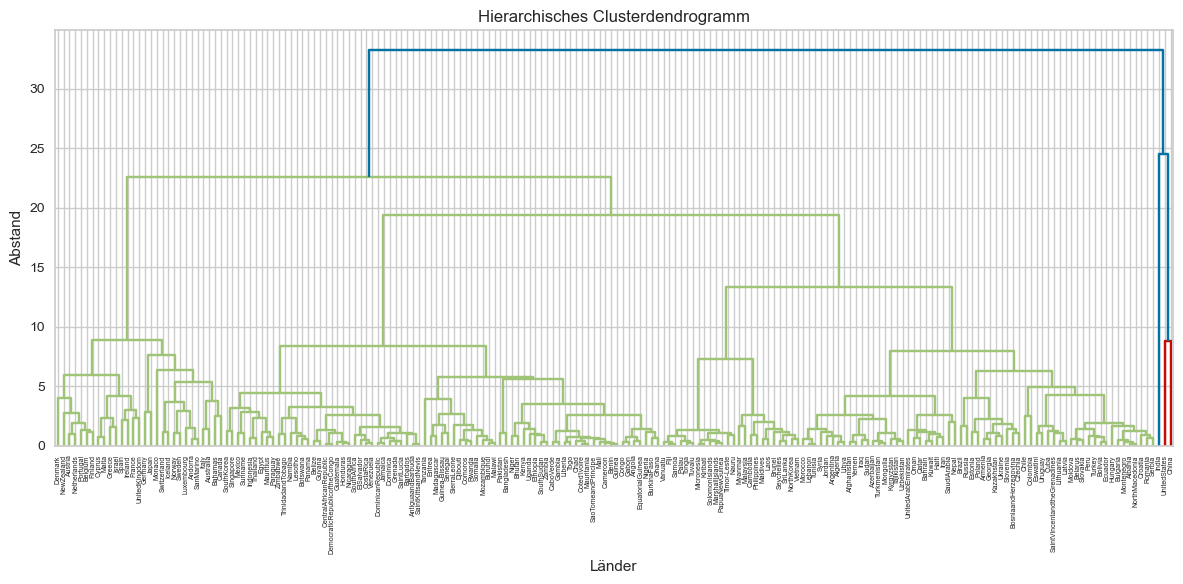

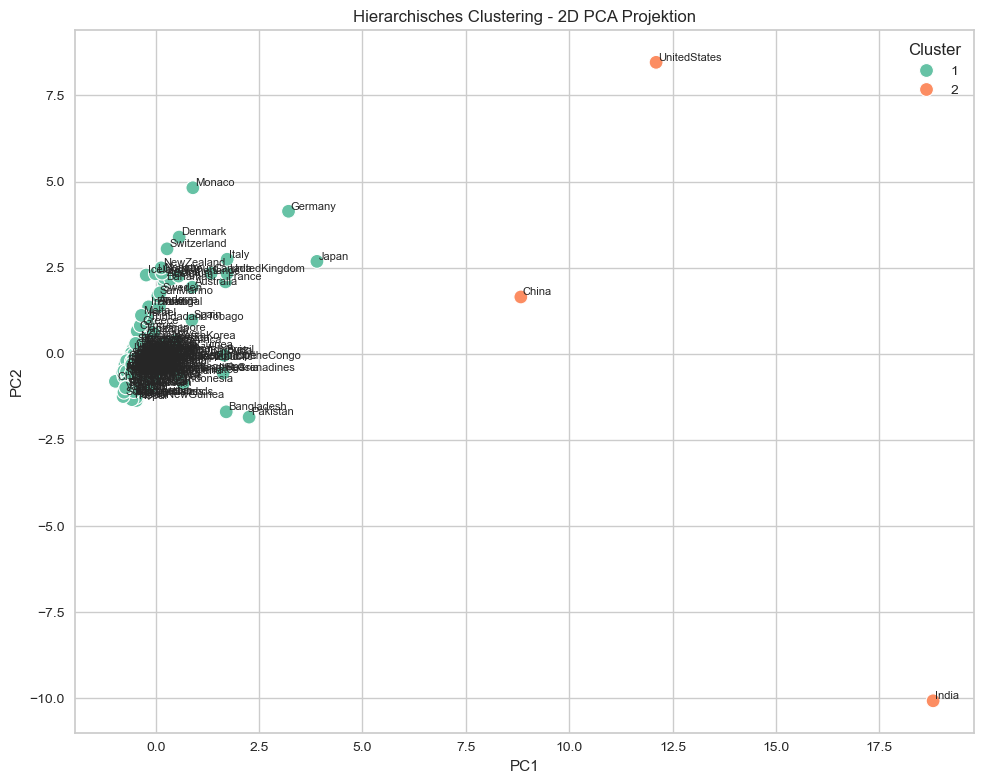


Cluster-Zusammenfassung (Durchschnittswerte):
          TotalExpenditure  PerCapitaExpenditure  EdentulismRate  \
hcluster                                                           
1              1015.733333             53.412698        7.660847   
2             65039.633333            149.833333        6.633333   

          PeriodontalRate  UntreatedCariesRate  \
hcluster                                         
1               18.441270            32.357143   
2               18.333333            25.900000   

          UntreatedDeciduousCaries1_9Rate  ProductivityLoss  \
hcluster                                                      
1                               41.692063       1011.938624   
2                               44.366667      43810.133333   

          TotalCancerNewCases_fill  FemaleCancerNewCases  MaleCancerNewCases  
hcluster                                                                      
1                       964.635498            360.707602          68

In [53]:
# Hierarchische Clusteranalyse
# Wir haben 192 Länder, diese Zahl ist für hierarchisches Clustering etwas klein. 
# Trotzdem wird die Methode getestet; durch Dendrogramm und PCA-Visualisierung können wir die Clusterstruktur grob untersuchen.

def hierarchical_clustering_pipeline(df, features, cluster_range=range(2,10)):
   
    if 'TotalCancerNewCases_fill' not in df.columns:
        if 'kmeans_cluster_no' in df.columns:
            df["TotalCancerNewCases_fill"] = df.groupby(
                ["ExpenditureGroup", "kmeans_cluster_no"]
            )["TotalCancerNewCases"].transform(lambda x: x.fillna(x.mean()))
        else:
            df["TotalCancerNewCases_fill"] = df.groupby(
                ["ExpenditureGroup"]
            )["TotalCancerNewCasesr"].transform(lambda x: x.fillna(x.mean()))

    X = df[features].fillna(df[features].mean())
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    Z = linkage(X_scaled, method='ward')

    c, _ = cophenet(Z, pdist(X_scaled))
    print(f"Cophenetische Korrelation: {c:.3f}")

    best_score = -1
    best_k = 2
    for k in cluster_range:
        clusters = fcluster(Z, t=k, criterion='maxclust')
        score = silhouette_score(X_scaled, clusters)
        print(f"n_clusters={k}, Silhouette Score={score:.3f}")
        if score > best_score:
            best_score = score
            best_k = k
    print(f"Optimale Clusteranzahl: {best_k}, Silhouette Score: {best_score:.3f}")
    
    df['hcluster'] = fcluster(Z, t=best_k, criterion='maxclust')

    plt.figure(figsize=(12,6))
    dendrogram(Z, labels=df["Location"].values, color_threshold=None)
    plt.title("Hierarchisches Clusterdendrogramm", fontsize=12)
    plt.xlabel("Länder")
    plt.ylabel("Abstand")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(10,8))
    sns.scatterplot(
        x=X_pca[:,0], y=X_pca[:,1], 
        hue=df['hcluster'], 
        palette='Set2', s=100
    )

    for i, txt in enumerate(df["Location"]):
        plt.text(X_pca[i,0]+0.05, X_pca[i,1]+0.05, txt, fontsize=8)

    plt.title("Hierarchisches Clustering - 2D PCA Projektion", fontsize=12)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
    
    cluster_summary = df.groupby("hcluster")[features].mean()
    print("\nCluster-Zusammenfassung (Durchschnittswerte):")
    print(cluster_summary)

    return df, best_k, best_score

features = [
    'TotalExpenditure', 'PerCapitaExpenditure',
    'EdentulismRate', 'PeriodontalRate', 'UntreatedCariesRate',
    'UntreatedDeciduousCaries1_9Rate', 'ProductivityLoss',
    'TotalCancerNewCases_fill', 'FemaleCancerNewCases', 'MaleCancerNewCases'
]

df, optimal_k, silhouette = hierarchical_clustering_pipeline(df, features)


#### **Regressionsmodelle**

In [54]:
df.isnull().sum()

Location                            0
TotalExpenditure                    0
PerCapitaExpenditure                0
EdentulismRate                      0
PeriodontalRate                     0
UntreatedCariesRate                 0
UntreatedDeciduousCaries1_9Rate     0
ProductivityLoss                    0
TotalCancerNewCases                18
FemaleCancerNewCases               18
MaleCancerNewCases                 18
ExpenditureGroup                    0
kmeans_cluster_no                   0
TotalCancerNewCases_fill            0
hcluster                            0
dtype: int64

In [55]:
df.columns

Index(['Location', 'TotalExpenditure', 'PerCapitaExpenditure',
       'EdentulismRate', 'PeriodontalRate', 'UntreatedCariesRate',
       'UntreatedDeciduousCaries1_9Rate', 'ProductivityLoss',
       'TotalCancerNewCases', 'FemaleCancerNewCases', 'MaleCancerNewCases',
       'ExpenditureGroup', 'kmeans_cluster_no', 'TotalCancerNewCases_fill',
       'hcluster'],
      dtype='object')

In [56]:
# Vorhersage des Produktivitätsverlusts mit Regressionsmodellen

results = []

df["TotalCancerNewCases_fill"] = df.groupby(
    ["ExpenditureGroup", "kmeans_cluster_no"]
)["TotalCancerNewCases"].transform(lambda x: x.fillna(x.mean()))

ziel = 'ProductivityLoss'  
merkmale = ['TotalExpenditure', 'PerCapitaExpenditure', 'EdentulismRate', 
            'PeriodontalRate', 'UntreatedCariesRate', 'TotalCancerNewCases_fill']

X = df[merkmale]
y = df[ziel]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressoren = [
    ("LineareRegression", LinearRegression()),
    ("KNN", KNeighborsRegressor()),
    ("CART", DecisionTreeRegressor()),
    ("RandomForest", RandomForestRegressor(random_state=42)),
    ("GradientBoosting", GradientBoostingRegressor(random_state=42)),
    ("XGBoost", XGBRegressor(random_state=42, eval_metric='rmse'))
]

for name, modell in regressoren:
    modell.fit(X_train, y_train)
    y_pred = modell.predict(X_test)
    
    results.append({
        "Modell": name,
        "R2": round(r2_score(y_test, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
print(results_df)


              Modell      R2       RMSE       MAE
0  LineareRegression  0.8788  1156.2920  555.6518
1                KNN  0.7560  1640.7891  616.1831
2               CART  0.7750  1575.7093  633.3513
3       RandomForest  0.8791  1154.9169  439.8851
4   GradientBoosting  0.9010  1045.1138  434.9410
5            XGBoost  0.8945  1078.8830  401.1981


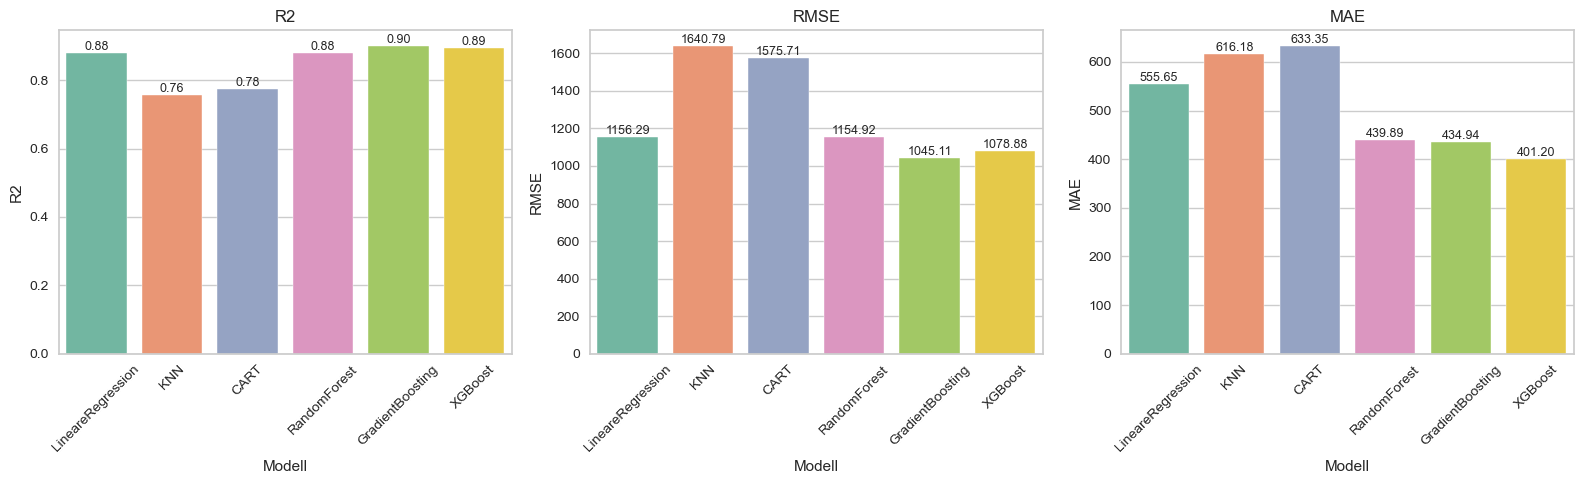

In [57]:
# Vergleich der Leistungskennzahlen verschiedener Modelle
metriken = ["R2", "RMSE", "MAE"]

plt.figure(figsize=(16, 5))

for i, metrike in enumerate(metriken, 1):
    plt.subplot(1, 3, i)
    sns.barplot(x="Modell", y=metrike, data=results_df, palette="Set2")
    
    for p in plt.gca().patches:
        plt.gca().annotate(f"{p.get_height():.2f}", 
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9)
    
    plt.title(metrike)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


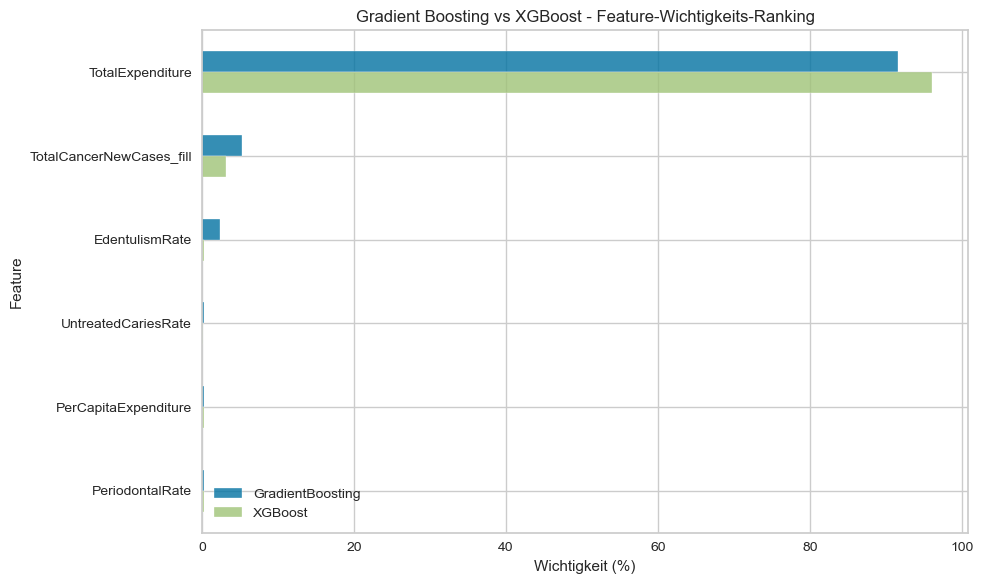

Feature-Wichtigkeits-Ranking (%) für Gradient Boosting und XGBoost:
                    Feature  GradientBoosting    XGBoost
0          TotalExpenditure         91.562051  95.986351
5  TotalCancerNewCases_fill          5.280864   3.120939
2            EdentulismRate          2.391441   0.258008
4       UntreatedCariesRate          0.309657   0.101930
1      PerCapitaExpenditure          0.242307   0.243147
3           PeriodontalRate          0.213680   0.289628


In [58]:
# Feature-Wichtigkeits-Ranking (%) für Gradient Boosting und XGBoost

# Gradient Boosting Modell
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
gb_importances = gb_model.feature_importances_

# XGBoost Modell
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='rmse'
)
xgb_model.fit(X_train, y_train)
xgb_importances = xgb_model.feature_importances_

# Gemeinsames DataFrame (% normalisiert)
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'GradientBoosting': gb_importances,
    'XGBoost': xgb_importances
})

# Normalisierung (in Prozent)
importance_df['GradientBoosting'] = (
    importance_df['GradientBoosting'] / importance_df['GradientBoosting'].sum() * 100
)
importance_df['XGBoost'] = (
    importance_df['XGBoost'] / importance_df['XGBoost'].sum() * 100
)

importance_df = importance_df.sort_values(by='GradientBoosting', ascending=False)

# Visualisierung
importance_df.set_index("Feature").plot(
    kind="barh", figsize=(10, 6), alpha=0.8
)
plt.xlabel("Wichtigkeit (%)")
plt.title("Gradient Boosting vs XGBoost - Feature-Wichtigkeits-Ranking")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

print("Feature-Wichtigkeits-Ranking (%) für Gradient Boosting und XGBoost:")
print(importance_df)


#### **Klassifikation**

In [59]:
# Klassifikation der Länder nach Ausgabengruppen mit Random Forest und Leistungsbewertung

df["TotalCancerNewCases_fill"] = df.groupby(
    ["ExpenditureGroup", "kmeans_cluster_no"]
)["TotalCancerNewCases"].transform(lambda x: x.fillna(x.mean()))

merkmale = ['PerCapitaExpenditure',
            'EdentulismRate', 'PeriodontalRate', 'UntreatedCariesRate',
            'UntreatedDeciduousCaries1_9Rate', 'ProductivityLoss',
            'TotalCancerNewCases_fill']
ziel = 'ExpenditureGroup'

X = df[merkmale].fillna(df[merkmale].mean())
y = LabelEncoder().fit_transform(df[ziel])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("Konfusionsmatrix:")
print(confusion_matrix(y_test, y_pred))
print("\nKlassifikationsbericht:")
print(classification_report(y_test, y_pred))

X_scaled = scaler.fit_transform(X)  
cv_results = cross_validate(rf, X_scaled, y, cv=10,
                            scoring=["accuracy", "f1_weighted", "roc_auc_ovr"])

print("\nErgebnisse der Kreuzvalidierung:")
print("Durchschnittliche Genauigkeit (Accuracy):", round(cv_results['test_accuracy'].mean(), 3))
print("Durchschnittlicher F1-Score:", round(cv_results['test_f1_weighted'].mean(), 3))
print("Durchschnittlicher ROC AUC (OVR):", round(cv_results['test_roc_auc_ovr'].mean(), 3))


Konfusionsmatrix:
[[14  0  5]
 [ 0 17  2]
 [ 5  3 12]]

Klassifikationsbericht:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        19
           1       0.85      0.89      0.87        19
           2       0.63      0.60      0.62        20

    accuracy                           0.74        58
   macro avg       0.74      0.74      0.74        58
weighted avg       0.74      0.74      0.74        58


Ergebnisse der Kreuzvalidierung:
Durchschnittliche Genauigkeit (Accuracy): 0.844
Durchschnittlicher F1-Score: 0.844
Durchschnittlicher ROC AUC (OVR): 0.954


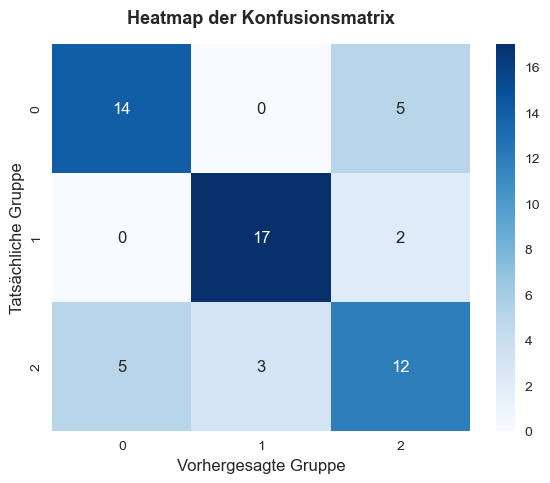

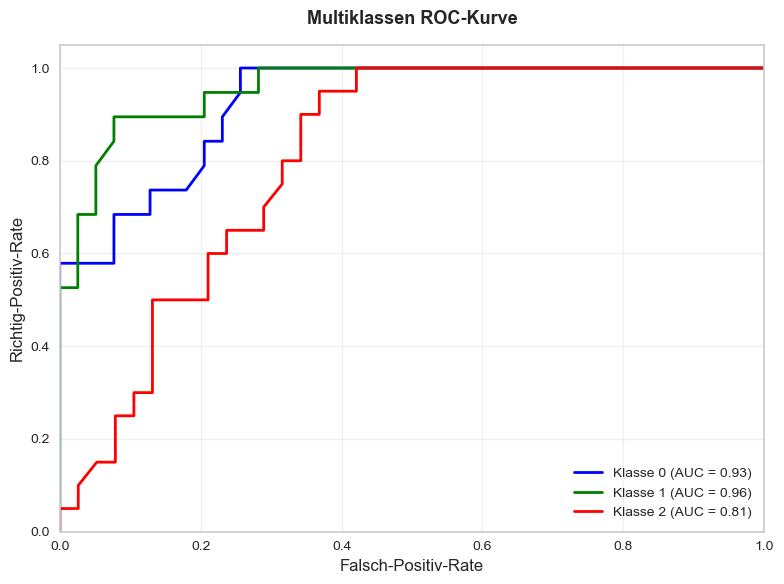

In [60]:
# Heatmap der Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))

plt.xlabel("Vorhergesagte Gruppe", fontsize=12)
plt.ylabel("Tatsächliche Gruppe", fontsize=12)
plt.title("Heatmap der Konfusionsmatrix", fontsize=13, weight="bold", pad=15)
plt.tight_layout()
plt.show()

# Multiklassen ROC-Kurve
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_pred_proba = rf.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))
farben = ["blue", "green", "red"]

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=farben[i % len(farben)],
             label=f'Klasse {i} (AUC = {roc_auc:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Falsch-Positiv-Rate", fontsize=12)
plt.ylabel("Richtig-Positiv-Rate", fontsize=12)
plt.title("Multiklassen ROC-Kurve", fontsize=13, weight="bold", pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


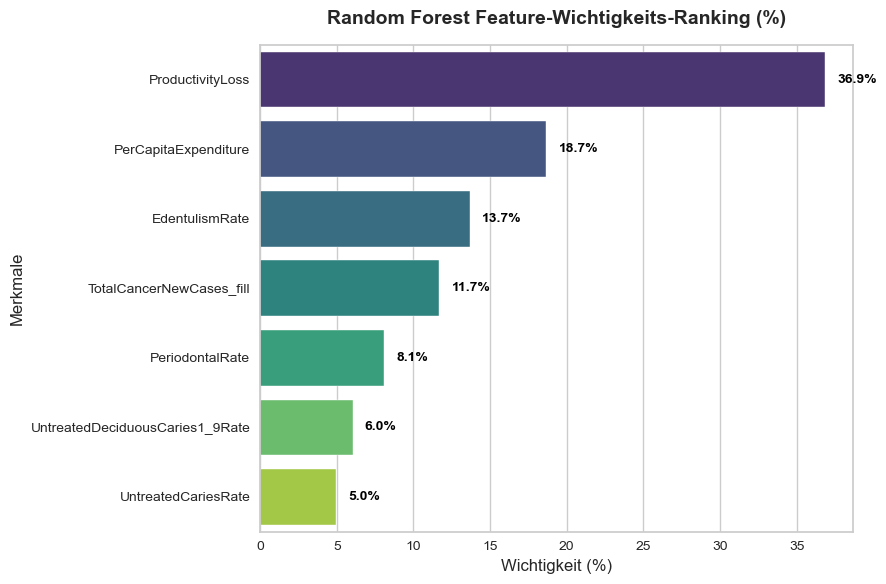

In [61]:
# Random Forest Modell: Wichtigkeit der Features zur Vorhersage der Ausgabengruppen

feat_importances = pd.Series(rf.feature_importances_, index=merkmale)
feat_importances = (feat_importances / feat_importances.sum()) * 100
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x=feat_importances, 
    y=feat_importances.index, 
    palette="viridis"
)

plt.title("Random Forest Feature-Wichtigkeits-Ranking (%)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Wichtigkeit (%)", fontsize=12)
plt.ylabel("Merkmale", fontsize=12)

for i, v in enumerate(feat_importances):
    ax.text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=10, weight="bold", color="black")

plt.tight_layout()
plt.show()
